In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from math import comb
from collections import Counter

from scipy import stats
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import diptest

In [2]:
from scipy.stats import dirichlet
dist = dirichlet([5, 5, 5])

In [3]:
def negative_log_likelihood(params, k, n):
    alpha, beta = params
    # Ensure alpha and beta are positive
    if alpha <= 0 or beta <= 0:
        return np.inf
    ll = stats.betabinom.logpmf(k, n, alpha, beta)
    return -ll.sum()

In [4]:
dist = dirichlet([1, 1])

print("PDF at [5,5,5]: ", dist.pdf([0.8, 0.2]))
print("Mean of disitrubtion: ", dist.mean())

PDF at [5,5,5]:  1.0
Mean of disitrubtion:  [0.5 0.5]


(array([214.,  95.,  79.,  60.,  63.,  52.,  85.,  66.,  77., 209.]),
 array([1.50179108e-06, 9.99990851e-02, 1.99996668e-01, 2.99994252e-01,
        3.99991835e-01, 4.99989419e-01, 5.99987002e-01, 6.99984585e-01,
        7.99982169e-01, 8.99979752e-01, 9.99977335e-01]),
 <BarContainer object of 10 artists>)

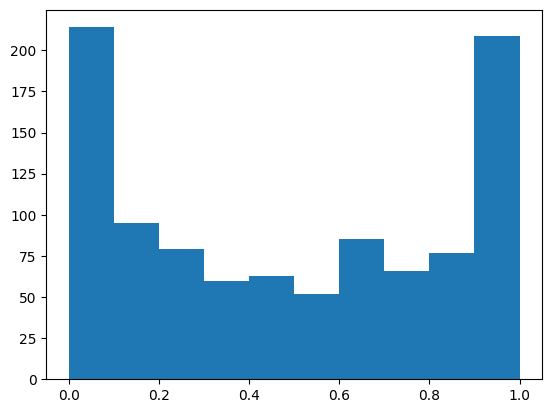

In [5]:
plt.hist(np.random.beta(0.5, 0.5, 1000))

(array([ 2.,  0.,  2.,  3.,  0., 10.,  2., 10.,  2.,  2.]),
 array([0.27272727, 0.31515152, 0.35757576, 0.4       , 0.44242424,
        0.48484848, 0.52727273, 0.56969697, 0.61212121, 0.65454545,
        0.6969697 ]),
 <BarContainer object of 10 artists>)

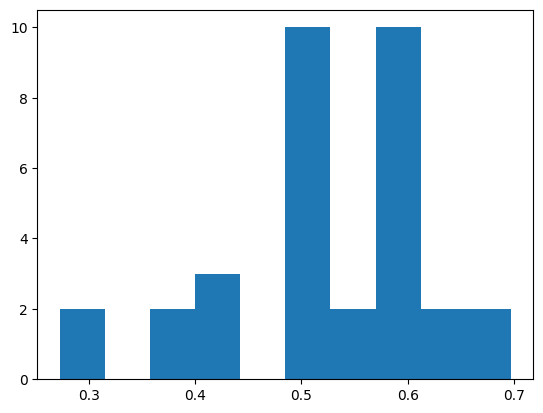

In [6]:
n = 33
plt.hist(np.random.binomial(n, 0.5, n)/n)

In [7]:
comb(33,3)

5456

In [8]:
hist_rr_counts = [15,
13,
19,
12,
16,
12,
17,
16,
14,
15,
13,
13,
13,
14,
12,
12,
14,
13,
15,
15,
14,
12,
16,
15,
15,
12,
12,
19,
13,
12,
12,
15]

myth_rr_counts = [21,
19,
18,
17,
17,
15,
14,
13,
12,
19,
15,
12,
20,
19,
14,
18,
17,
13]

/var/folders/5p/ph3v1s590p18wh0s9jk1sk3c0000gn/T/ipykernel_2168/3832034280.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hist_rr_counts, myth_rr_counts], labels=['Hist', 'Myth'])


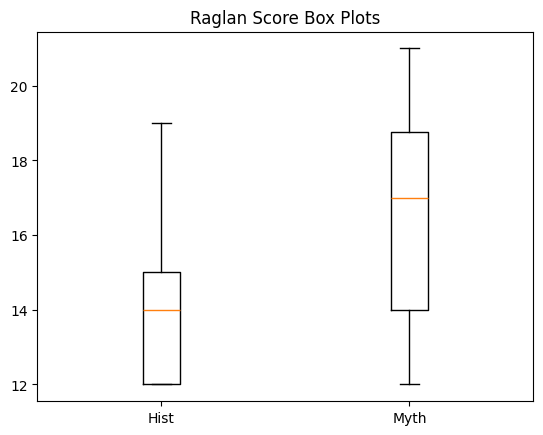

In [9]:
plt.boxplot([hist_rr_counts, myth_rr_counts], labels=['Hist', 'Myth'])
plt.title("Raglan Score Box Plots")
plt.show()
plt.close()

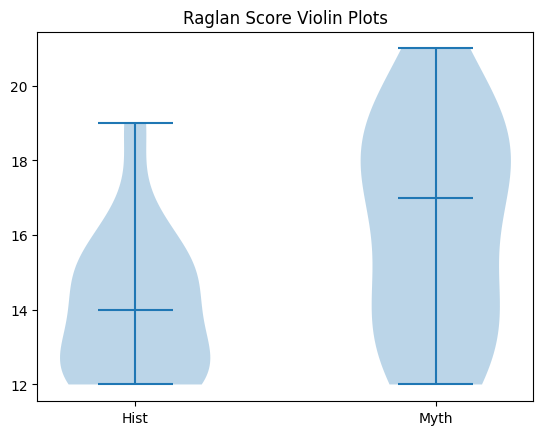

In [10]:
plt.violinplot([hist_rr_counts, myth_rr_counts], showmedians=True, 
               #labels=['Hist', 'Myth'], 
               )
labels = ['Hist', 'Myth']
plt.xticks(np.arange(1, len(labels) + 1), labels)
plt.title("Raglan Score Violin Plots")
plt.show()
plt.close()

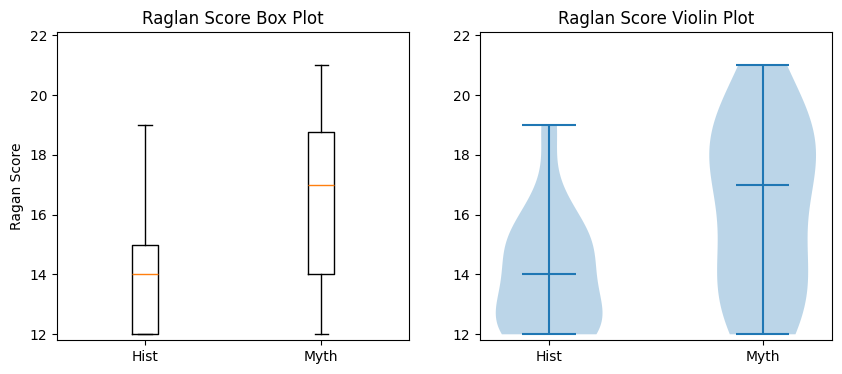

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ax[0].boxplot([hist_rr_counts, myth_rr_counts], tick_labels=['Hist', 'Myth'])
ax[0].set_title("Raglan Score Box Plot")
ax[0].set_ylabel("Ragan Score")
ax[0].set_ylim(11.8, 22.1)

ax[1].violinplot([hist_rr_counts, myth_rr_counts], showmedians=True, 
               #labels=['Hist', 'Myth'], 
               )
ax[1].set_ylim(11.8, 22.1)
labels = ['Hist', 'Myth']
ax[1].set_xticks(np.arange(1, len(labels) + 1), labels)
ax[1].set_title("Raglan Score Violin Plot")

plt.show()
plt.close()

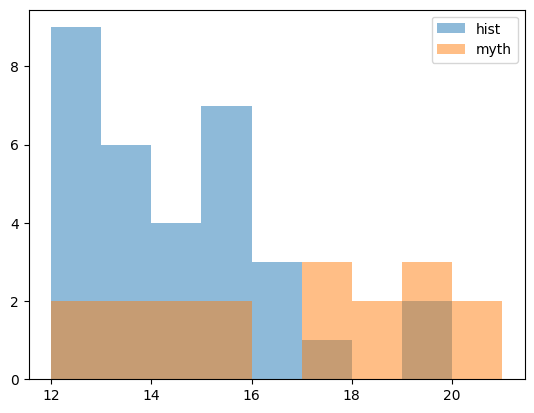

In [12]:
bins_list = np.arange(12, 22, 1)

plt.hist(hist_rr_counts, label='hist', alpha=0.5, density=False, bins=bins_list)
plt.hist(myth_rr_counts, label='myth', alpha=0.5, density=False, bins=bins_list)
plt.legend()
plt.show()
plt.close()

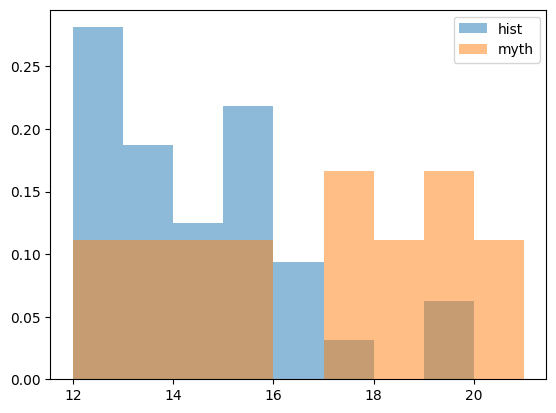

In [13]:
bins_list = np.arange(12, 22, 1)

plt.hist(hist_rr_counts, label='hist', alpha=0.5, density=True, bins=bins_list)
plt.hist(myth_rr_counts, label='myth', alpha=0.5, density=True, bins=bins_list)
plt.legend()
plt.show()
plt.close()

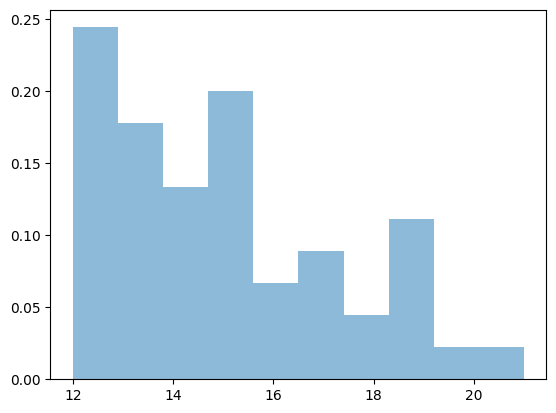

In [14]:
plt.hist(hist_rr_counts + myth_rr_counts, alpha=0.5, density=True)
plt.show()
plt.close()

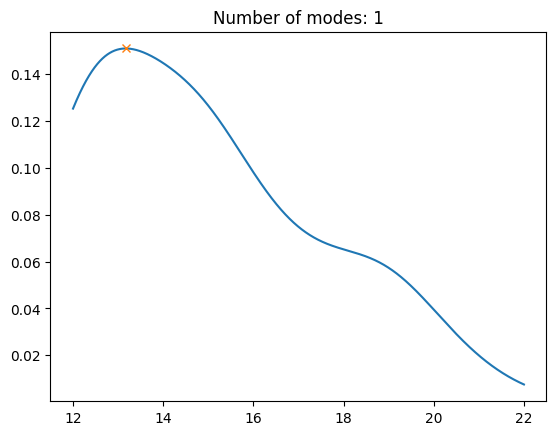

Dip statistic: 0.09, p-value: 0.0022797190369819864


In [15]:
# Create a Kernel Density Estimate
data = hist_rr_counts + myth_rr_counts

kde = gaussian_kde(data)
#x_vals = np.linspace(min(data), max(data), 100)
x_vals = np.arange(min(data), max(data)+1, 0.001)
kde_vals = kde(x_vals)

# Find peaks in the KDE
peaks, _ = find_peaks(kde_vals, height=0.05, distance=50) # Adjust height and distance as needed

# Plotting for visualization
plt.plot(x_vals, kde_vals)
plt.plot(x_vals[peaks], kde_vals[peaks], "x")
plt.title(f"Number of modes: {len(peaks)}")
plt.show()

# Calculate both the dip statistic and p-value
dip, pval = diptest.diptest(np.array(data))
print(f"Dip statistic: {dip}, p-value: {pval}")

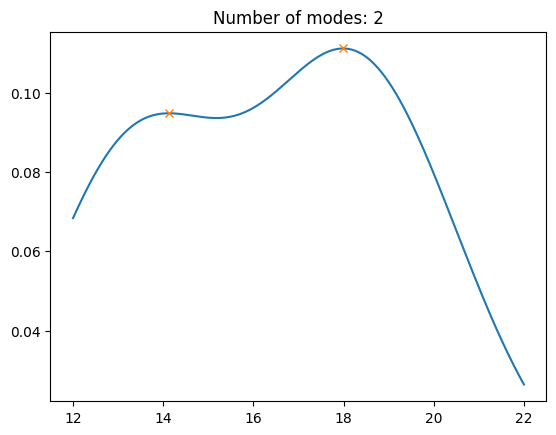

Dip statistic: 0.08888888888888888, p-value: 0.25526950280959815


In [16]:
# Create a Kernel Density Estimate
data = myth_rr_counts

kde = gaussian_kde(data)
#x_vals = np.linspace(min(data), max(data), 100)
x_vals = np.arange(min(data), max(data)+1, 0.001)
kde_vals = kde(x_vals)

# Find peaks in the KDE
peaks, _ = find_peaks(kde_vals, height=0.05, distance=50) # Adjust height and distance as needed

# Plotting for visualization
plt.plot(x_vals, kde_vals)
plt.plot(x_vals[peaks], kde_vals[peaks], "x")
plt.title(f"Number of modes: {len(peaks)}")
plt.show()

# Calculate both the dip statistic and p-value
dip, pval = diptest.diptest(np.array(data))
print(f"Dip statistic: {dip}, p-value: {pval}")

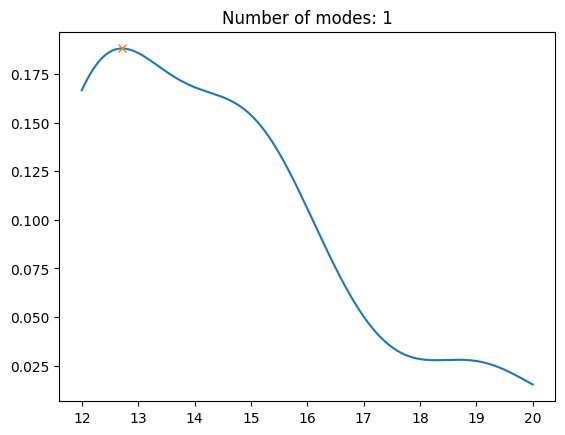

Dip statistic: 0.109375, p-value: 0.0020821630306497863


In [17]:
# Create a Kernel Density Estimate
data = hist_rr_counts

kde = gaussian_kde(data)
#x_vals = np.linspace(min(data), max(data), 100)
x_vals = np.arange(min(data), max(data)+1, 0.001)
kde_vals = kde(x_vals)

# Find peaks in the KDE
peaks, _ = find_peaks(kde_vals, height=0.05, distance=50) # Adjust height and distance as needed

# Plotting for visualization
plt.plot(x_vals, kde_vals)
plt.plot(x_vals[peaks], kde_vals[peaks], "x")
plt.title(f"Number of modes: {len(peaks)}")
plt.show()

# Calculate both the dip statistic and p-value
dip, pval = diptest.diptest(np.array(data))
print(f"Dip statistic: {dip}, p-value: {pval}")

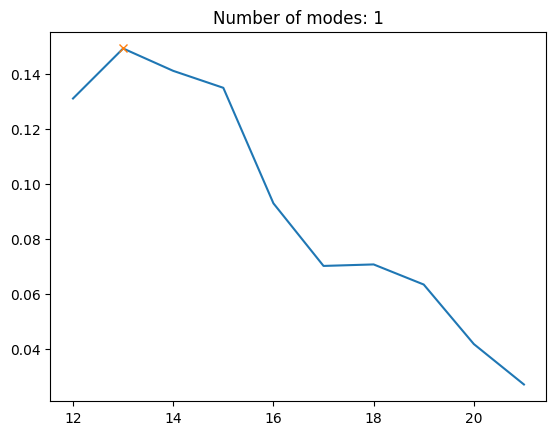

Dip statistic: 0.10333333333333332, p-value: 0.0


In [18]:
n = 10**2

# Create a Kernel Density Estimate
data = np.concatenate((np.random.choice(hist_rr_counts, size=n, replace=True), np.random.choice(myth_rr_counts, size=n, replace=True)))

kde = gaussian_kde(data)
#x_vals = np.linspace(min(data), max(data), 100)
x_vals = np.arange(min(data), max(data)+1, 1)
kde_vals = kde(x_vals)

# Find peaks in the KDE
peaks, _ = find_peaks(kde_vals, height=0.05, distance=50) # Adjust height and distance as needed

# Plotting for visualization
plt.plot(x_vals, kde_vals)
plt.plot(x_vals[peaks], kde_vals[peaks], "x")
plt.title(f"Number of modes: {len(peaks)}")
plt.show()

# Calculate both the dip statistic and p-value
dip, pval = diptest.diptest(np.array(data))
print(f"Dip statistic: {dip}, p-value: {pval}")

In [19]:
n = 10**2
n_runs = 10**4
dip_list = []
p_list = []

for i in range(0, n_runs):
    data = np.concatenate((np.random.choice(hist_rr_counts, size=n, replace=True), np.random.choice(myth_rr_counts, size=n, replace=True)))
    data = np.random.choice(data, size=len(hist_rr_counts + myth_rr_counts), replace=True)
    dip, pval = diptest.diptest(np.array(data))
    dip_list.append(dip)
    p_list.append(pval)

0.09364587023809526 0.01372525118229397


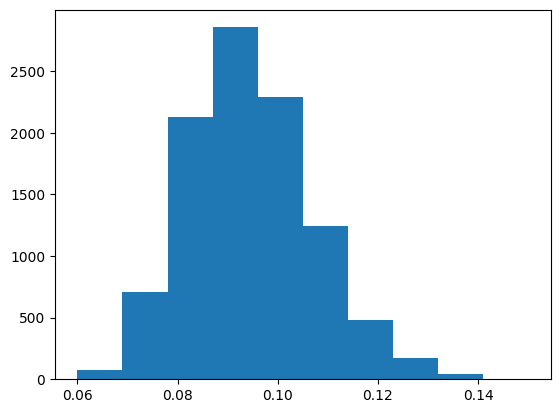

In [20]:
plt.hist(dip_list)
print(np.mean(dip_list), np.std(dip_list))

0.007555289068543499 0.01759296247869211


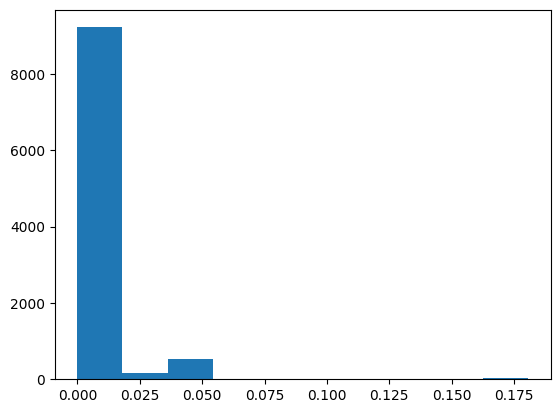

In [21]:
plt.hist(p_list)
print(np.mean(p_list), np.std(p_list))

0.028368117453480488 0.005434235900822183


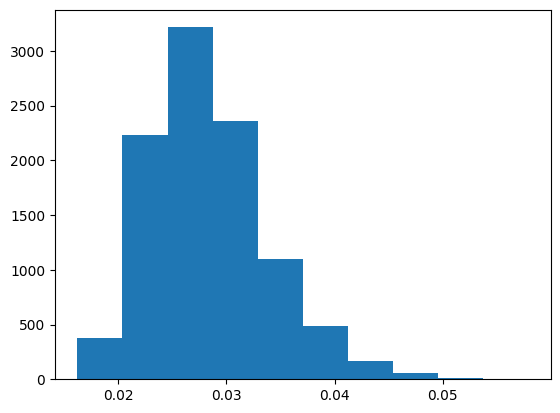

In [22]:
n = 10**2
n_runs = 10**4
dip_list = []
p_list = []

for i in range(0, n_runs):
    data = (np.random.normal(1, 10, n))
    #data = np.random.choice(data, size=len(hist_rr_counts + myth_rr_counts), replace=True)
    dip, pval = diptest.diptest(np.array(data))
    dip_list.append(dip)
    p_list.append(pval)

plt.hist(dip_list)
print(np.mean(dip_list), np.std(dip_list))

In [23]:
hist_mean = np.mean(hist_rr_counts)
hist_std = np.std(hist_rr_counts)
myth_mean = np.mean(myth_rr_counts)
myth_std = np.std(myth_rr_counts)

(hist_mean - myth_mean)/np.sqrt(2*(hist_std**2 + myth_std**2))

np.float64(-0.46411895243762125)

[1.]
[1.]


/var/folders/5p/ph3v1s590p18wh0s9jk1sk3c0000gn/T/ipykernel_2168/564969395.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  parameters, cov_matrix = curve_fit(fit_function, bin_centers, entries)
/var/folders/5p/ph3v1s590p18wh0s9jk1sk3c0000gn/T/ipykernel_2168/564969395.py:53: OptimizeWarning: Covariance of the parameters could not be estimated
  parameters, cov_matrix = curve_fit(fit_function, bin_centers, entries)


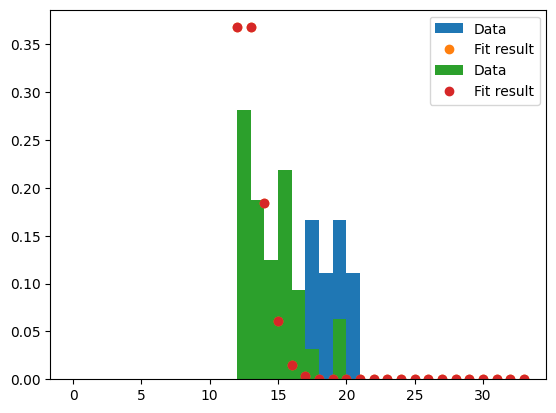

In [24]:
from scipy.optimize import curve_fit
from scipy.special import factorial
from scipy.stats import poisson

# get poisson deviated random numbers
#data = np.concatenate((np.random.choice(hist_rr_counts, size=n, replace=True), np.random.choice(myth_rr_counts, size=n, replace=True)))
data = myth_rr_counts

# the bins should be of integer width, because poisson is an integer distribution
bins = np.arange(0, 22)
entries, bin_edges, patches = plt.hist(data, bins=bins, density=True, label='Data')

# calculate bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])


def fit_function(k, lamb):
    '''poisson function, parameter lamb is the fit parameter'''
    return poisson.pmf(k, lamb)


# fit with curve_fit
parameters, cov_matrix = curve_fit(fit_function, bin_centers, entries)
print(parameters)

# plot poisson-deviation with fitted parameter
x_plot = np.arange(0, 22)

plt.plot(
    x_plot + 12,
    fit_function(x_plot, *parameters),
    marker='o', linestyle='',
    label='Fit result',
)

#data = np.concatenate((np.random.choice(hist_rr_counts, size=n, replace=True), np.random.choice(myth_rr_counts, size=n, replace=True)))
data = hist_rr_counts

# the bins should be of integer width, because poisson is an integer distribution
bins = np.arange(0, 22)
entries, bin_edges, patches = plt.hist(data, bins=bins, density=True, label='Data')

# calculate bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])


def fit_function(k, lamb):
    '''poisson function, parameter lamb is the fit parameter'''
    return poisson.pmf(k, lamb)


# fit with curve_fit
parameters, cov_matrix = curve_fit(fit_function, bin_centers, entries)
print(parameters)

# plot poisson-deviation with fitted parameter
x_plot = np.arange(0, 22)

plt.plot(
    x_plot + 12,
    fit_function(x_plot, *parameters),
    marker='o', linestyle='',
    label='Fit result',
)
plt.legend()
plt.show()

In [25]:
bins

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [26]:
# from scipy.optimize import minimize
# from scipy.special import factorial
# from scipy import stats


# def poisson(k, lamb):
#     """poisson pdf, parameter lamb is the fit parameter"""
#     return (lamb**k/factorial(k)) * np.exp(-lamb)


# def negative_log_likelihood(params, data):
#     """
#     The negative log-Likelihood-Function
#     """

#     lnl = - np.sum(np.log(poisson(data, params[0])))
#     return lnl

# def negative_log_likelihood(params, data):
#     ''' better alternative using scipy '''
#     return -stats.poisson.logpmf(data, params[0]).sum()


# # get poisson deviated random numbers
# data = np.random.poisson(15, 10000)
# data = myth_rr_counts

# # minimize the negative log-Likelihood

# result = minimize(negative_log_likelihood,  # function to minimize
#                   x0=np.array(15.0),            # start value
#                   args=(data,),             # additional arguments for function
#                   method='Powell',          # minimization method, see docs
#                   )
# # result is a scipy optimize result object, the fit parameters 
# # are stored in result.x
# print(result)

# # plot poisson-distribution with fitted parameter
# x_plot = np.arange(0, 22)

# plt.plot(
#     x_plot,
#     stats.poisson.pmf(x_plot, result.x),
#     marker='o', linestyle='',
#     label='Fit result',
# )

# data = np.random.poisson(12, 10000)
# data = hist_rr_counts

# # minimize the negative log-Likelihood

# result = minimize(negative_log_likelihood,  # function to minimize
#                   x0=np.array(12.0),            # start value
#                   args=(data,),             # additional arguments for function
#                   method='Powell',          # minimization method, see docs
#                   )
# # result is a scipy optimize result object, the fit parameters 
# # are stored in result.x
# print(result)

# # plot poisson-distribution with fitted parameter
# x_plot = np.arange(0, 22)

# plt.plot(
#     x_plot,
#     stats.poisson.pmf(x_plot, result.x),
#     marker='o', linestyle='',
#     label='Fit result',
# )
# plt.legend()
# plt.show()

Fitted parameters: a=7.80, b=2.72, loc=0.00, scale=1.00
Fitted parameters: a=16.43, b=9.22, loc=0.00, scale=1.00


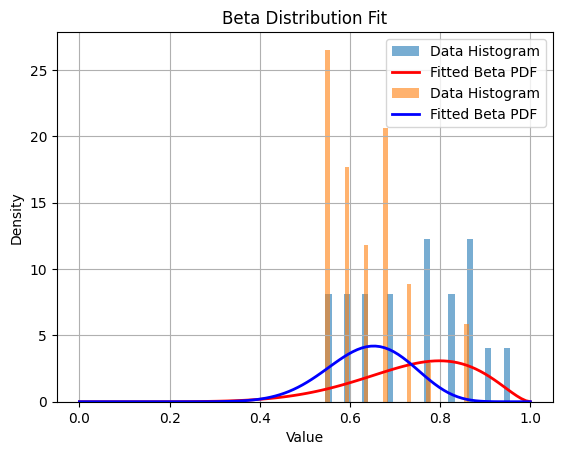

In [27]:
from scipy.stats import beta

data = [x/22 for x in myth_rr_counts]

params = beta.fit(data, floc=0, fscale=1) 
a_fit, b_fit, loc_fit, scale_fit = params
print(f"Fitted parameters: a={a_fit:.2f}, b={b_fit:.2f}, loc={loc_fit:.2f}, scale={scale_fit:.2f}")

# Create x values for plotting the PDF
x = np.linspace(0, 1, 100)

# Plot the histogram of the data
plt.hist(data, bins=30, density=True, alpha=0.6, label='Data Histogram')

# Plot the fitted Beta PDF
plt.plot(x, beta.pdf(x, a_fit, b_fit, loc=loc_fit, scale=scale_fit), 
            'r-', lw=2, label='Fitted Beta PDF')

plt.title('Beta Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
# plt.show()
# plt.close()

data = [x/22 for x in hist_rr_counts]

params = beta.fit(data, floc=0, fscale=1) 
a_fit, b_fit, loc_fit, scale_fit = params
print(f"Fitted parameters: a={a_fit:.2f}, b={b_fit:.2f}, loc={loc_fit:.2f}, scale={scale_fit:.2f}")

# Create x values for plotting the PDF
x = np.linspace(0, 1, 100)

# Plot the histogram of the data
plt.hist(data, bins=30, density=True, alpha=0.6, label='Data Histogram')

# Plot the fitted Beta PDF
plt.plot(x, beta.pdf(x, a_fit, b_fit, loc=loc_fit, scale=scale_fit), 
            'b-', lw=2, label='Fitted Beta PDF')

plt.title('Beta Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()
plt.close()

Fitted parameters: a=7.80, b=2.72, loc=0.00, scale=1.00


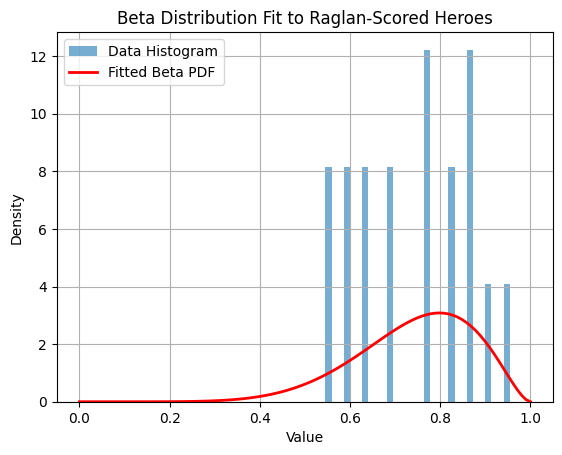

In [28]:
data = [x/22 for x in myth_rr_counts]

params = beta.fit(data, floc=0, fscale=1) 
a_fit, b_fit, loc_fit, scale_fit = params
print(f"Fitted parameters: a={a_fit:.2f}, b={b_fit:.2f}, loc={loc_fit:.2f}, scale={scale_fit:.2f}")

# Create x values for plotting the PDF
x = np.linspace(0, 1, 100)

# Plot the histogram of the data
plt.hist(data, bins=30, density=True, alpha=0.6, label='Data Histogram')

# Plot the fitted Beta PDF
plt.plot(x, beta.pdf(x, a_fit, b_fit, loc=loc_fit, scale=scale_fit), 
            'r-', lw=2, label='Fitted Beta PDF')

plt.title('Beta Distribution Fit to Raglan-Scored Heroes')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
# plt.show()
# plt.close()

In [29]:
7.80/(7.80 + 2.72)*22, 16.43/(16.43 + 9.22)*22

(16.311787072243348, 14.092007797270956)

In [30]:
(7.80-0.333)/(7.80 + 2.72 - 0.667)*22, (16.43-0.333)/(16.43 + 9.22 - 0.667)*22

(16.672485537399776, 14.174998999319541)

In [31]:
(7.80-1)/(7.80 + 2.72 - 2)*22, (16.43-1)/(16.43 + 9.22 - 2)*22

(17.558685446009388, 14.353488372093022)

In [32]:
(7.80-1)/(7.80 + 2.72 - 2), (16.43-1)/(16.43 + 9.22 - 2)

(0.7981220657276995, 0.6524312896405919)

In [33]:
(7.80 * 2.72)/(((7.80 + 2.72)**2*((7.80 + 2.72 + 1)))), (16.43 * 9.22)/(((16.43 + 9.22)**2*((16.43 + 9.22 + 1))))

(0.016641004881763028, 0.008639657620332102)

In [34]:
(16.311787072243348 - 14.092007797270956)/ (2*np.sqrt(0.016641004881763028 + 0.008639657620332102)*np.sqrt(22))

np.float64(1.4882443099859521)

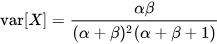

Fitted parameters: a=9.10, b=4.31, loc=0.00, scale=1.00


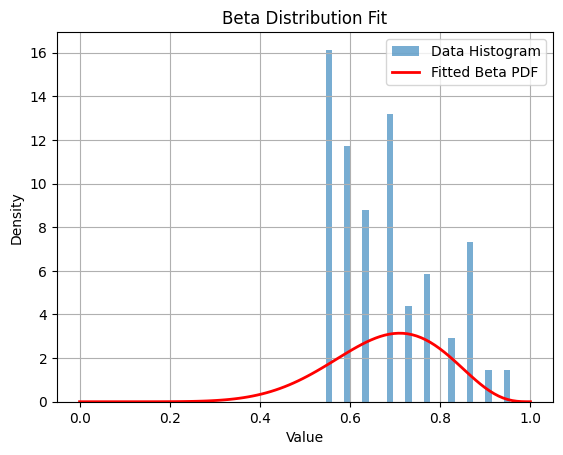

In [35]:
data = [x/22 for x in hist_rr_counts + myth_rr_counts]

params = beta.fit(data, floc=0, fscale=1) 
a_fit, b_fit, loc_fit, scale_fit = params
print(f"Fitted parameters: a={a_fit:.2f}, b={b_fit:.2f}, loc={loc_fit:.2f}, scale={scale_fit:.2f}")

# Create x values for plotting the PDF
x = np.linspace(0, 1, 100)

# Plot the histogram of the data
plt.hist(data, bins=30, density=True, alpha=0.6, label='Data Histogram')

# Plot the fitted Beta PDF
plt.plot(x, beta.pdf(x, a_fit, b_fit, loc=loc_fit, scale=scale_fit), 
            'r-', lw=2, label='Fitted Beta PDF')

plt.title('Beta Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()
plt.close()

In [36]:
from factor_analyzer import FactorAnalyzer

In [37]:
from sklearn.decomposition import PCA, FactorAnalysis

In [38]:
df = pd.read_excel(r"/Users/aaronadair/Downloads/raglan_hero_counts_GH.xlsx", sheet_name="cleanded_counts")
for i in range(1, 23):
    df[i] = df[i].apply(lambda x: 1 if x == "X" else 0)

In [39]:
df.columns

Index([      'Name', 'Historical',            1,            2,            3,
                  4,            5,            6,            7,            8,
                  9,           10,           11,           12,           13,
                 14,           15,           16,           17,           18,
                 19,           20,           21,           22],
      dtype='object')

In [40]:
df.head()

,Name,Historical,1,2,3,4,5,6,7,8,...,13,14,15,16,17,18,19,20,21,22
0,Agathocles of Syracuse,Hist,0,0,0,1,0,1,1,1,...,1,0,1,1,1,1,0,1,1,0
1,Alcibiades,Hist,1,1,0,0,0,0,0,0,...,1,0,1,1,1,1,1,1,0,1
2,Alexander the Great,Hist,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,0,1
3,Apollonius of Tyana,Hist,0,1,0,1,1,1,1,1,...,0,0,1,0,0,1,1,1,1,1
4,Aratus of Sicyon,Hist,0,1,0,1,1,1,1,1,...,1,0,1,1,1,1,0,1,0,1




 PCA :

[[-0.017769    0.03671181  0.06700363]
 [-0.09509321  0.06293941 -0.02129271]
 [ 0.26171657  0.33772399  0.28660816]
 [ 0.33077603  0.20982326 -0.14800734]
 [ 0.19430411 -0.02578492  0.44061711]
 [ 0.22952548  0.35942406  0.08099792]
 [ 0.34584802  0.29478406 -0.27623829]
 [ 0.23732432  0.37676974 -0.06370853]
 [-0.12402509 -0.06838937 -0.10197081]
 [ 0.32022959 -0.30076175 -0.02694522]
 [ 0.00504368 -0.05529206 -0.16333972]
 [-0.0462827   0.02578046 -0.02228439]
 [-0.05889127 -0.01848117 -0.01258402]
 [ 0.27126467 -0.08896286  0.20782106]
 [-0.22099781  0.08756576  0.07970183]
 [-0.16469408  0.09956468 -0.27038959]
 [ 0.23023649 -0.21804424 -0.32714482]
 [ 0.09009192 -0.11397891 -0.1784353 ]
 [ 0.29278117 -0.13392199  0.06070064]
 [ 0.20860235 -0.15542484 -0.23849178]
 [ 0.24214722 -0.34271126 -0.22584328]
 [ 0.15573519 -0.36487409  0.44541426]]


 Unrotated FA :

[[ 0.01039647 -0.02777258  0.04147478]
 [ 0.05404538 -0.06089687  0.02015666]
 [ 0.00897614  0.13294198  0.29948

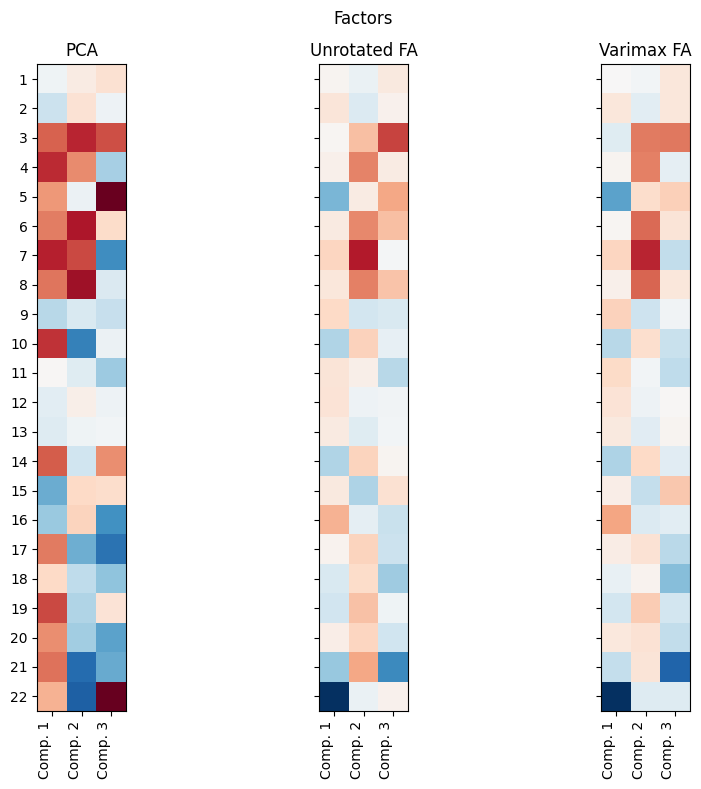

In [41]:
n_comps = 3
feature_names = np.arange(1, 23)

methods = [
    ("PCA", PCA()),
    ("Unrotated FA", FactorAnalysis()),
    ("Varimax FA", FactorAnalysis(rotation="varimax")),
]
fig, axes = plt.subplots(ncols=len(methods), figsize=(10, 8), sharey=True)

for ax, (method, fa) in zip(axes, methods):
    fa.set_params(n_components=n_comps)
    fa.fit(df[feature_names])

    components = fa.components_.T
    print("\n\n %s :\n" % method)
    print(components)

    vmax = np.abs(components).max()
    ax.imshow(components, cmap="RdBu_r", vmax=vmax, vmin=-vmax)
    ax.set_yticks(np.arange(len(feature_names)))
    ax.set_yticklabels(feature_names)
    ax.set_title(str(method))
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Comp. 1", "Comp. 2", "Comp. 3"])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
fig.suptitle("Factors")
plt.tight_layout()
plt.show()

In [42]:
pca = PCA(n_components=5)

X_train = pca.fit_transform(df[feature_names])
X_test = pca.transform(df[feature_names])

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.14488067 0.11680138 0.10774696 0.08604395 0.07354904]


Chi-square value: 281.00562769142067
P-value: 0.013637764608545407
KMO Model: 0.4462785317031222


/Users/aaronadair/miniconda3/lib/python3.10/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/Users/aaronadair/miniconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


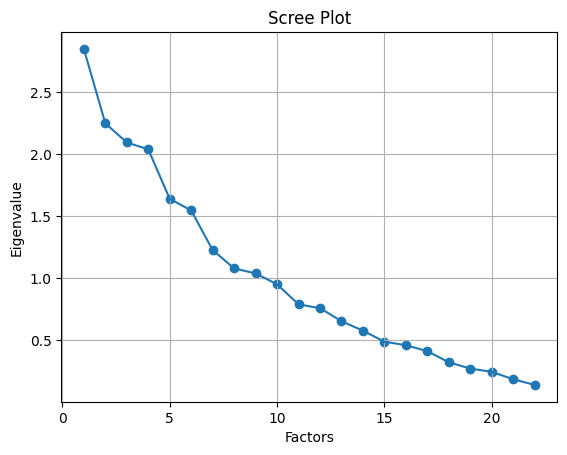

[[-8.61674541e-02  1.27180981e-01 -4.81661650e-02]
 [-2.66151438e-01  1.70939388e-01 -9.88703497e-03]
 [-1.01043690e-01 -2.37373264e-01  3.75011107e-01]
 [ 1.75731559e-01 -9.49456046e-02  4.37134954e-01]
 [ 3.65354312e-02 -4.40736856e-01  5.14809851e-02]
 [ 3.25128665e-02 -6.25659205e-02  5.22292203e-01]
 [ 3.08829263e-01  1.18023708e-01  6.35166007e-01]
 [ 5.70458666e-04 -4.19962244e-02  6.13944313e-01]
 [ 3.86568279e-02  3.72302346e-01 -2.53628327e-01]
 [ 4.91691355e-01 -1.12637566e-01 -7.27595803e-02]
 [ 3.47159909e-01  4.83689445e-01 -9.30114863e-02]
 [ 2.51114684e-03  2.71523834e-01 -4.14461205e-02]
 [ 1.80130707e-03  3.73653899e-01 -2.74567180e-01]
 [ 3.68801208e-01 -1.33060052e-01  3.55269469e-02]
 [-4.78127257e-01 -4.57941916e-02 -1.05652433e-01]
 [-1.56737594e-01  4.79671532e-01  2.49389401e-02]
 [ 3.46647497e-01  4.27661175e-02  1.79626371e-02]
 [ 2.46467184e-01  5.58120936e-03  4.73487399e-02]
 [ 3.47692072e-01 -1.81335845e-01  9.02596740e-02]
 [ 3.57384314e-01  5.07735977e-

/Users/aaronadair/miniconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/aaronadair/miniconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [43]:
data = df[feature_names]

# Apply Bartlett's test
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(data)
print(f'Chi-square value: {chi_square_value}\nP-value: {p_value}')

# Apply KMO test
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(data)
print(f'KMO Model: {kmo_model}')

# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation="varimax")
fa.fit(data)

# Check Eigenvalues
eigen_values, vectors = fa.get_eigenvalues()
plt.scatter(range(1, data.shape[1]+1), eigen_values)
plt.plot(range(1, data.shape[1]+1), eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# Perform factor analysis with the determined number of factors
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(data)

# Get factor loadings
loadings = fa.loadings_
print(loadings)

# Get variance of each factor
fa.get_factor_variance()

# Get factor scores
factor_scores = fa.transform(data)
print(factor_scores)

Testing nonsense for now

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Example: Creating a contingency table from raw data
data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Preference': ['A', 'B', 'A', 'A', 'B', 'B', 'A', 'B']
})
contingency_table = pd.crosstab(data['Gender'], data['Preference'])
print("Contingency Table:")
print(contingency_table)

Contingency Table:
Preference  A  B
Gender          
Female      1  3
Male        3  1


In [45]:
chi2, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

In [46]:
print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected Frequencies:")
print(expected_frequencies)

# Decision based on p-value
alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value ({p_value:.4f}) < alpha ({alpha}), reject the null hypothesis.")
    print("There is a significant association between the two variables.")
else:
    print(f"\nSince p-value ({p_value:.4f}) >= alpha ({alpha}), fail to reject the null hypothesis.")
    print("There is no significant association between the two variables.")


Chi-squared statistic: 0.50
P-value: 0.4795
Degrees of freedom: 1
Expected Frequencies:
[[2. 2.]
 [2. 2.]]

Since p-value (0.4795) >= alpha (0.05), fail to reject the null hypothesis.
There is no significant association between the two variables.


In [47]:
hist_rr_counts + myth_rr_counts

[15,
 13,
 19,
 12,
 16,
 12,
 17,
 16,
 14,
 15,
 13,
 13,
 13,
 14,
 12,
 12,
 14,
 13,
 15,
 15,
 14,
 12,
 16,
 15,
 15,
 12,
 12,
 19,
 13,
 12,
 12,
 15,
 21,
 19,
 18,
 17,
 17,
 15,
 14,
 13,
 12,
 19,
 15,
 12,
 20,
 19,
 14,
 18,
 17,
 13]

In [48]:
["Hist" for x in hist_rr_counts] + ["Myth" for x in myth_rr_counts]

['Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Hist',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth',
 'Myth']

In [49]:
data = pd.DataFrame({
    'Type': ["Hist" for x in hist_rr_counts] + ["Myth" for x in myth_rr_counts],
    'Counts': hist_rr_counts + myth_rr_counts
})
contingency_table = pd.crosstab(data['Type'], data['Counts'])
print("Contingency Table:")
print(contingency_table)

Contingency Table:
Counts  12  13  14  15  16  17  18  19  20  21
Type                                          
Hist     9   6   4   7   3   1   0   2   0   0
Myth     2   2   2   2   0   3   2   3   1   1


In [50]:
chi2, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected Frequencies:")
print(expected_frequencies)

# Decision based on p-value
alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value ({p_value:.4f}) < alpha ({alpha}), reject the null hypothesis.")
    print("There is a significant association between the two variables.")
else:
    print(f"\nSince p-value ({p_value:.4f}) >= alpha ({alpha}), fail to reject the null hypothesis.")
    print("There is no significant association between the two variables.")


Chi-squared statistic: 15.39
P-value: 0.0809
Degrees of freedom: 9
Expected Frequencies:
[[7.04 5.12 3.84 5.76 1.92 2.56 1.28 3.2  0.64 0.64]
 [3.96 2.88 2.16 3.24 1.08 1.44 0.72 1.8  0.36 0.36]]

Since p-value (0.0809) >= alpha (0.05), fail to reject the null hypothesis.
There is no significant association between the two variables.


In [51]:
contingency_table.iloc[1]*np.sum(contingency_table.iloc[0])/np.sum(contingency_table.iloc[1])

Counts
12    3.555556
13    3.555556
14    3.555556
15    3.555556
16    0.000000
17    5.333333
18    3.555556
19    5.333333
20    1.777778
21    1.777778
Name: Myth, dtype: float64

In [52]:
stats.chisquare(contingency_table.iloc[0], contingency_table.iloc[1]*np.sum(contingency_table.iloc[0])/np.sum(contingency_table.iloc[1]))

/Users/aaronadair/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:7335: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp


Power_divergenceResult(statistic=np.float64(inf), pvalue=np.float64(0.0))

In [53]:
1/13.

0.07692307692307693

In [54]:
new_counts_list = [16,
16,
15,
14,
15,
15,
13,
15,
14,
16,
16,
17,
14,
10,
14,
12,
11,
12,
16,
12,
13,
13,
15, 
#17,
]

(array([1., 1., 3., 0., 3., 4., 0., 5., 5., 1.]),
 array([10. , 10.7, 11.4, 12.1, 12.8, 13.5, 14.2, 14.9, 15.6, 16.3, 17. ]),
 <BarContainer object of 10 artists>)

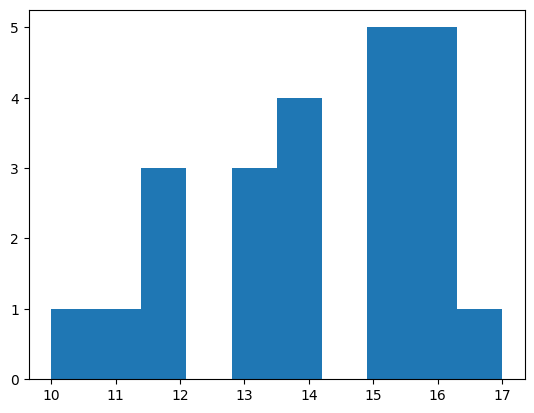

In [55]:
plt.hist(new_counts_list)

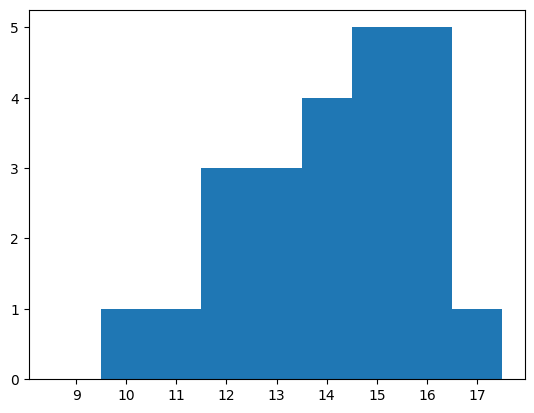

In [56]:
bins_list = np.arange(8.5, 18.5, 1)
xticks_list = np.arange(9, 18, 1)
xticks_list = [int(x) for x in xticks_list]

plt.hist(new_counts_list, bins=bins_list)

# Get the current axes
ax = plt.gca()

# Set the major locator for the x-axis to MaxNLocator with integer=True
import matplotlib.ticker as tck
ax.xaxis.set_major_locator(tck.MaxNLocator(integer=True))

In [57]:
[x-8 for x in xticks_list]

[1, 2, 3, 4, 5, 6, 7, 8, 9]

Fitted parameters: a=4.82, b=0.94, loc=0.00, scale=1.00


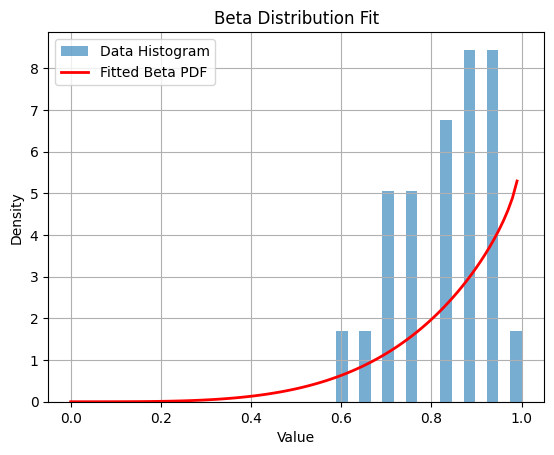

In [58]:
data = [x/17.0001 for x in new_counts_list]

params = beta.fit(data, floc=0, fscale=1) 
a_fit, b_fit, loc_fit, scale_fit = params
print(f"Fitted parameters: a={a_fit:.2f}, b={b_fit:.2f}, loc={loc_fit:.2f}, scale={scale_fit:.2f}")

# Create x values for plotting the PDF
x = np.linspace(0, 1, 100)

# Plot the histogram of the data
plt.hist(data, bins=16, density=True, alpha=0.6, label='Data Histogram')

# Plot the fitted Beta PDF
plt.plot(x, beta.pdf(x, a_fit, b_fit, loc=loc_fit, scale=scale_fit), 
            'r-', lw=2, label='Fitted Beta PDF')

plt.title('Beta Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()
plt.close()

In [59]:
from scipy.optimize import minimize
from scipy.stats import binom

In [60]:
# Observed data
data = hist_rr_counts
n_trials = 22

# Define the negative log-likelihood function
def neg_log_likelihood(p, data, n_trials):
    return -np.sum(binom.logpmf(data, n_trials, p))

# Initial guess for p
initial_p = 0.5

# Minimize the negative log-likelihood
result = minimize(neg_log_likelihood, initial_p, args=(data, n_trials), bounds=[(0, 1)])

estimated_p_mle = result.x[0]
print(f"Estimated probability of success (p) using MLE: {estimated_p_mle:.4f}")

Estimated probability of success (p) using MLE: 0.5000


In [61]:
import scipy

22.0 0.6392045420542503


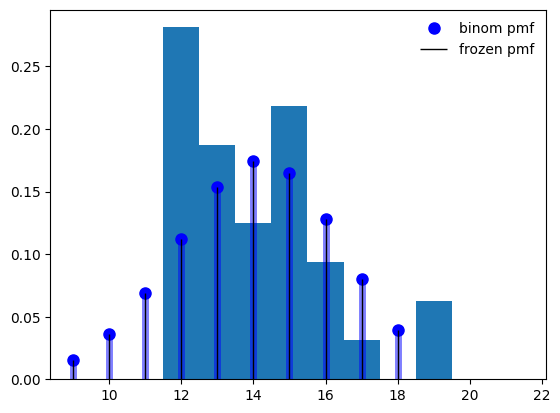

In [62]:
params = scipy.stats.fit(binom,hist_rr_counts, bounds={"n":[22]})

n = params.params.n
hist_n = n
p = params.params.p

print(n, p)

x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(0.99, n, p))
plt.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='binom pmf')
plt.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)

plt.hist(hist_rr_counts, bins=np.arange(11.5, 22.5, 1), density=True)

rv = binom(n, p)
plt.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')
plt.legend(loc='best', frameon=False)
plt.show()

22.0 0.7398989857763448


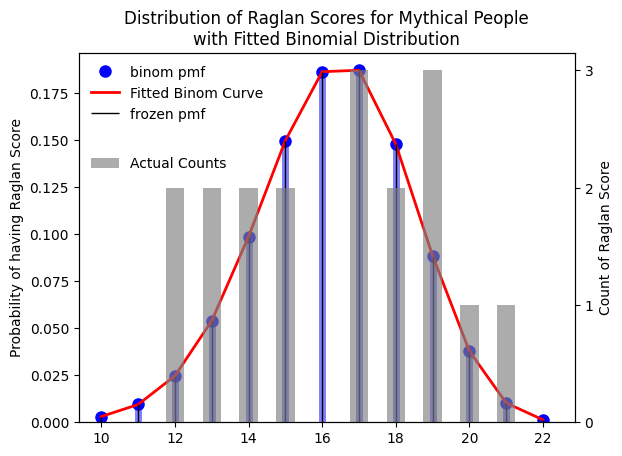

In [63]:
params = scipy.stats.fit(binom,myth_rr_counts, bounds={"n":[22]}
                         )

n = params.params.n
p = params.params.p

print(n, p)

x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(1.00, n, p))
x = np.arange(10, n+1, 1)

fig, ax1 = plt.subplots()

ax1.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='binom pmf')
ax1.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)


ax1.plot(x, binom.pmf(x, n, p), 
            'r-', lw=2, label='Fitted Binom Curve')

rv = binom(n, p)
ax1.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')

ax1.set_ylim(ymin=0)
ax1.legend(loc='upper left', frameon=False)

ax2 = ax1.twinx()

_, bins, rects = ax2.hist(myth_rr_counts, bins=np.arange(10.25, n + 0.75, 0.5), 
         density=False, color='grey', label="Actual Counts", alpha=0.65)

ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(loc='center left', bbox_to_anchor=(0.00, 0.7), frameon=False)

plt.title("Distribution of Raglan Scores for Mythical People\nwith Fitted Binomial Distribution")
plt.xlabel("Raglan Score")
ax1.set_ylabel("Probability of having Raglan Score")
ax2.set_ylabel("Count of Raglan Score")

plt.show()
plt.close()

In [64]:
n, p, params.params.n

(np.float64(22.0), np.float64(0.7398989857763448), np.float64(22.0))

In [65]:
observed_data = [myth_rr_counts.count(i) for i in range(0, 23)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, params.params.n, p)*tot_obs for x in range(0, 23)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

Chi-square statistic: 6.25395523939792
p-value: 0.9995883042856639


In [66]:
n

np.float64(22.0)

In [67]:
stats.chisquare(observed_data, expected_data)

Power_divergenceResult(statistic=np.float64(15.577339349051773), pvalue=np.float64(0.8362945231523129))

In [68]:
# Binomial
observed_data = [myth_rr_counts.count(i) for i in range(12, 23)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, n, p)*tot_obs for x in range(12, 23)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

# Binomial Unweighted Coin
observed_data = [new_counts_list.count(i) for i in range(9, 18)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, n, 0.5)*tot_obs for x in range(9, 18)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]

chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

# Uniform
observed_data = [myth_rr_counts.count(i) for i in range(12, 23)]
tot_obs = np.sum(observed_data)
expected_data = [tot_obs/len(observed_data) for x in range(12, 23)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

Chi-square statistic: 6.034524817045614
p-value: 0.8123543214062773
Chi-square statistic: 15.010052503190177
p-value: 0.05895028970124258
Chi-square statistic: 4.563894523326571
p-value: 0.9183455824319591


In [69]:
observed_data, tot_obs

([2, 2, 2, 2, 0, 3, 2, 3, 1, 1, 0], np.int64(18))

In [70]:
expected_data

[np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365),
 np.float64(1.6363636363636365)]

In [71]:
int(hist_n), int(n)

(22, 22)

In [72]:
# Example for binomial test
k_successes = int(hist_n) # Observed number of successes
n_trials = 22 # Total number of trials
p_expected = p # Expected probability of success under the null hypothesis

binomial_test_result = stats.binomtest(k_successes, n_trials, p_expected)
print(f"Binomial Test: P-value = {binomial_test_result.pvalue:.3f}")

Binomial Test: P-value = 0.002


In [73]:
scipy.stats.fit(binom,new_counts_list, bounds={"n":[0,17]})

  params: FitParams(n=np.float64(17.0), p=np.float64(0.8286444963973074), loc=np.float64(0.0))
 success: True
 message: 'Optimization terminated successfully.'

In [74]:
params = scipy.stats.fit(binom,new_counts_list, bounds={"n":[0,17]})

In [75]:
params.params.p

np.float64(0.8286445002691729)

17.0 0.8286444920288706


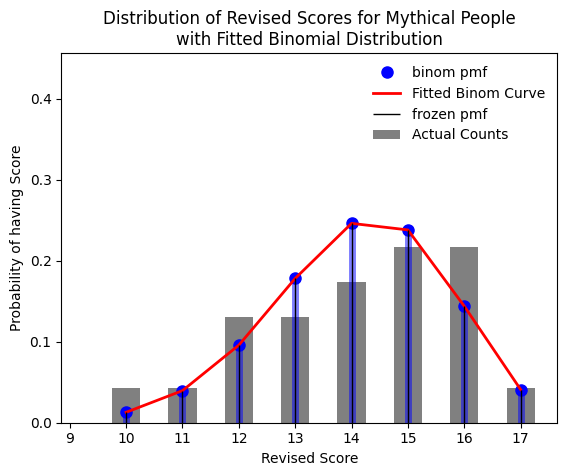

In [76]:
params = scipy.stats.fit(binom, new_counts_list, bounds={"n":[17]}
                         )

n = params.params.n
p = params.params.p

print(n, p)

x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(1.00, n, p))
x = np.arange(10, n+1, 1)
plt.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='binom pmf')
plt.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)


plt.plot(x, binom.pmf(x, n, p), 
            'r-', lw=2, label='Fitted Binom Curve')

rv = binom(n, p)
plt.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')


n, bins, rects = plt.hist(new_counts_list, bins=np.arange(9.25, 17.75, 0.5), 
         density=True, color='grey', label="Actual Counts")
sum_n = np.sum(n)
for i in range(len(rects)):
    rects[i].set_height(rects[i].get_height() / sum_n)

plt.legend(loc='best', frameon=False)

plt.title("Distribution of Revised Scores for Mythical People\nwith Fitted Binomial Distribution")
plt.xlabel("Revised Score")
plt.ylabel("Probability of having Score")

plt.show()
plt.close()

17.0 0.8286444958606829


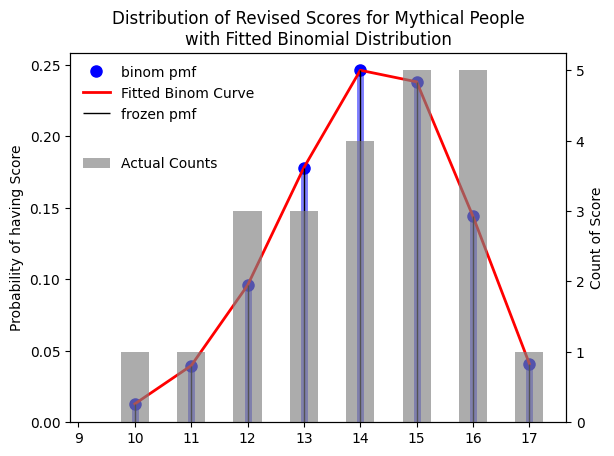

In [77]:
params = scipy.stats.fit(binom, new_counts_list, bounds={"n":[17]}
                         )

n = params.params.n
p = params.params.p

print(n, p)

x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(1.00, n, p))
x = np.arange(10, n+1, 1)

fig, ax1 = plt.subplots()

ax1.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='binom pmf')
ax1.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)


ax1.plot(x, binom.pmf(x, n, p), 
            'r-', lw=2, label='Fitted Binom Curve')

rv = binom(n, p)
ax1.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')

ax1.set_ylim(ymin=0)

ax1.legend(loc='best', frameon=False)


ax2 = ax1.twinx()

_, bins, rects = ax2.hist(new_counts_list, bins=np.arange(9.25, 17.75, 0.5), 
         density=False, color='grey', label="Actual Counts", alpha=0.65)

ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(loc='center left', bbox_to_anchor=(0.00, 0.7), frameon=False)

plt.title("Distribution of Revised Scores for Mythical People\nwith Fitted Binomial Distribution")
plt.xlabel("Revised Score")
ax1.set_ylabel("Probability of having Score")
ax2.set_ylabel("Count of Score")

plt.show()
plt.close()

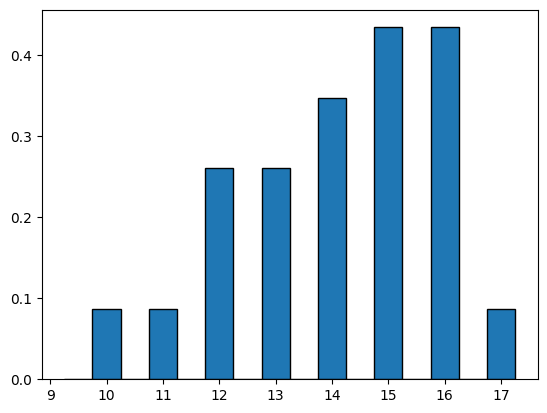

In [78]:
_, bins, rects = plt.hist(new_counts_list, bins=np.arange(9.25, 17.75, 0.5), edgecolor='k', density=True)

# 3. Modify the height of specific bars or all bars
# Example: Double the height of the first bar
rects[0].set_height(rects[0].get_height() / 2)

In [79]:
n

np.float64(17.0)

In [80]:
# observed_data = [x for x in Counter(new_counts_list).values()]
# tot_obs = np.sum(observed_data)
# expected_data = [binom.pmf(x, n, p)*tot_obs for x in Counter(new_counts_list).keys()]
# expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


# chi_square_test_statistic, p_value = stats.chisquare(
#     observed_data, expected_data)

# # chi square test statistic and p value
# print('chi_square_test_statistic is : ' +
#       str(chi_square_test_statistic))
# print('p_value : ' + str(p_value))

# df = len(observed_data) - 1


# # find Chi-Square critical value
# print(stats.chi2.ppf(1-0.05, df=df))

In [81]:
# Binomial
observed_data = [new_counts_list.count(i) for i in range(9, 18)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, n, p)*tot_obs for x in range(9, 18)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

# Uniform
observed_data = [new_counts_list.count(i) for i in range(9, 18)]
tot_obs = np.sum(observed_data)
expected_data = [tot_obs/len(observed_data) for x in range(9, 18)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

Chi-square statistic: 1.4084868949855869
p-value: 0.994125237399817
Chi-square statistic: 6.568300099700897
p-value: 0.5838421207055049


In [82]:
stats.chisquare(observed_data)

Power_divergenceResult(statistic=np.float64(11.043478260869566), pvalue=np.float64(0.19924781100779873))

In [83]:
observed_data = [new_counts_list.count(i) for i in range(0, 18)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, n, p)*tot_obs for x in range(0, 18)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

Chi-square statistic: 1.426694223667918
p-value: 0.9999997486509526


In [84]:
observed_data

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 3, 3, 4, 5, 5, 1]

In [85]:
expected_data

[np.float64(2.1776838966194396e-12),
 np.float64(1.7902511111780306e-10),
 np.float64(6.925866721059793e-09),
 np.float64(1.6746124865661816e-07),
 np.float64(2.834344010902333e-06),
 np.float64(3.563658662204963e-05),
 np.float64(0.00034466428731247633),
 np.float64(0.0026191545268861977),
 np.float64(0.015832202133030705),
 np.float64(0.0765616909756415),
 np.float64(0.29619088871132515),
 np.float64(0.9114802034797422),
 np.float64(2.2038774228267233),
 np.float64(4.099060033003784),
 np.float64(5.663519829494369),
 np.float64(5.477553297725135),
 np.float64(3.311058210342899),
 np.float64(0.941863756994199)]

In [86]:
[new_counts_list.count(i) for i in range(10, 18)]

[1, 1, 3, 3, 4, 5, 5, 1]

In [87]:
new_counts_list

[16,
 16,
 15,
 14,
 15,
 15,
 13,
 15,
 14,
 16,
 16,
 17,
 14,
 10,
 14,
 12,
 11,
 12,
 16,
 12,
 13,
 13,
 15]

In [88]:
initial_guesses = [0.51, 0.51]  # Initial guess for alpha and beta
bounds = [(1e-6, None), (1e-6, None)] # Ensure alpha and beta are positive

In [89]:
# Example data (replace with your actual data)
observed_counts = np.array(new_counts_list)
num_trials = 17 # Or an array of n values if they vary per observation

result = minimize(negative_log_likelihood, initial_guesses, args=(observed_counts, num_trials), bounds=bounds, method='L-BFGS-B')

estimated_alpha, estimated_beta = result.x

print(estimated_alpha, estimated_beta)

38.92159255074858 8.048031287819407


In [90]:
estimated_alpha / (estimated_alpha + estimated_beta)

np.float64(0.8286545509608498)

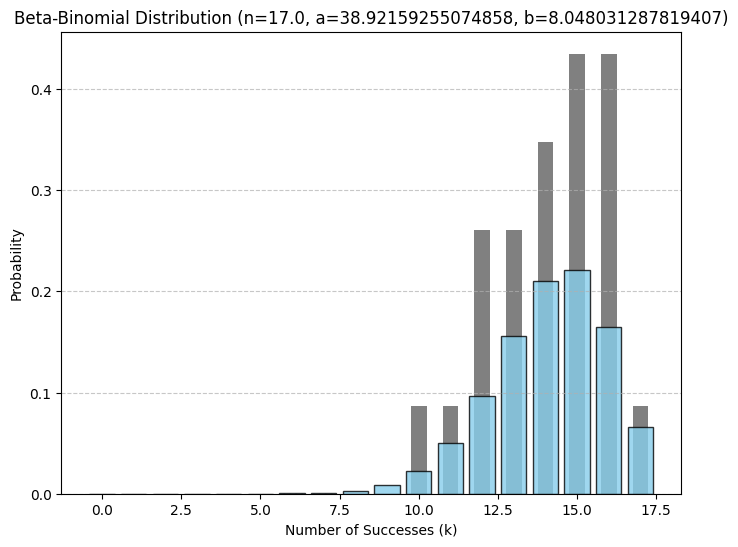

In [91]:
k = np.arange(0, num_trials + 1)

# Calculate the Probability Mass Function (PMF)
pmf = stats.betabinom.pmf(k, num_trials, estimated_alpha, estimated_beta)

# Plot the Beta-Binomial distribution
plt.figure(figsize=(8, 6))

plt.hist(new_counts_list, bins=np.arange(0.25, 17.75, 0.5), 
         density=True, color='grey', label="Actual Counts")

plt.bar(k, pmf, color='skyblue', edgecolor='black', alpha=0.8)
plt.title(f'Beta-Binomial Distribution (n={n}, a={estimated_alpha}, b={estimated_beta})')
plt.xlabel('Number of Successes (k)')
plt.ylabel('Probability')
# plt.xticks([val for val in k])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

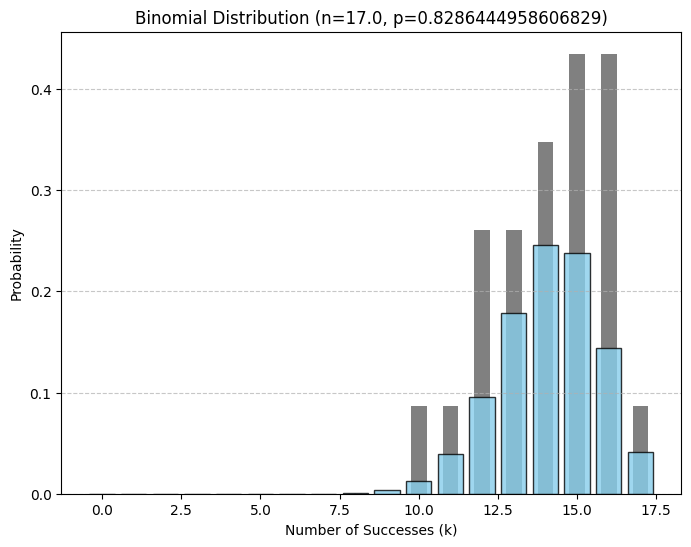

In [92]:
k = np.arange(0, num_trials + 1)

# Calculate the Probability Mass Function (PMF)
pmf = stats.binom.pmf(k, num_trials, p)

# Plot the Beta-Binomial distribution
plt.figure(figsize=(8, 6))

plt.hist(new_counts_list, bins=np.arange(0.25, 17.75, 0.5), 
         density=True, color='grey', label="Actual Counts")

plt.bar(k, pmf, color='skyblue', edgecolor='black', alpha=0.8)
plt.title(f'Binomial Distribution (n={n}, p={p})')
plt.xlabel('Number of Successes (k)')
plt.ylabel('Probability')
# plt.xticks([val for val in k])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [93]:
pmf

array([9.46819085e-14, 7.78370048e-12, 3.01124640e-10, 7.28092385e-09,
       1.23232348e-07, 1.54941681e-06, 1.49854038e-05, 1.13876284e-04,
       6.88356614e-04, 3.32876917e-03, 1.28778647e-02, 3.96295741e-02,
       9.58207575e-02, 1.78220001e-01, 2.46239993e-01, 2.38154491e-01,
       1.43959053e-01, 4.09505981e-02])

In [94]:
np.sum(pmf[10:])

np.float64(0.9958523322860077)

In [95]:
p

np.float64(0.8286444958606829)

In [688]:
df = pd.read_excel(r"/Users/aaronadair/Downloads/raglan_hero_counts_GH.xlsx", sheet_name="cleaned_counts").fillna('')

print(df.to_latex(index=False))

\begin{tabular}{llllllllllllllllllllllllr}
\toprule
Name & Status & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 & 15 & 16 & 17 & 18 & 19 & 20 & 21 & 22 & TOTAL \\
\midrule
Agathocles of Syracuse & Hist &  &  &  & X &  & X & X & X & X & X & X & X & X & ? & X & X & X & X &  & X & X &  & 15 \\
Alcibiades & Hist & X & X &  &  &  &  &  &  &  & X & X & X & X &  & X & X & X & X & X & X &  & X & 13 \\
Alexander the Great & Hist & X & X & X & X & X & X & X & X &  & X & X & X & X & X & X & X &  & X & X & X &  & X & 19 \\
Apollonius of Tyana & Hist &  & X &  & X & X & X & X & X &  & ? &  &  &  &  & X &  &  & X & X & X & X & X & 12 \\
Aratus of Sicyon & Hist &  & X &  & X & X & X & X & X & X & X & X &  & X &  & X & X & X & X &  & X &  & X & 16 \\
Aristotle & Hist & X & X & X &  &  &  &  & X & X & X &  & X & X & ? & X & ? & X &  &  & X &  & X & 12 \\
Caesar Augustus & Hist & X & X & X & X & X & X &  & X & X & ? & X & X & X & X & X & X &  & X &  &  & X & X & 17 \\
Caligula & Hist & X 

In [689]:
df = pd.read_excel(r"/Users/aaronadair/Downloads/raglan_hero_counts_GH.xlsx", sheet_name="cleaned_revised_counts v2").fillna('')

print(df.sort_values(by=['TOTAL','Name'], ascending=[False,True]).to_latex(index=False))

\begin{tabular}{llllllllllllllllllr}
\toprule
Name & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 & 15 & 16 & 17 & TOTAL \\
\midrule
Dionysus & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & 17 \\
Yudhishthira & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & 17 \\
Krishna & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X &  & X & 16 \\
Moses & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X & X &  & 16 \\
Nezha & X & X & X & X & X & X & X & X & X & X &  & X & X & X & X & X & X & 16 \\
Oedipus & X & X &  & X & X & X & X & X & X & X & X & X & X & X & X & X & X & 16 \\
Theseus & X & X & X & X & X & X & X & X & X & X & X & X & X & X &  & X & X & 16 \\
Zeus & X & X & X & X & X & X & X & X & X & X & X & X & X &  & X & X & X & 16 \\
Fionn mac Cumhaill & X & X & X & X & X & X & X & X & X & X & X & X & X &  & X &  & X & 15 \\
Heracles & X & X & X & X & X & X & X &  & X & X &  & X & X & X & X & X & X & 15 \\
Jason & X & 

In [899]:
version_str = "v2"

if version_str == "v2":
    df = pd.read_excel(r"/Users/aaronadair/Downloads/raglan_hero_counts_GH.xlsx", sheet_name="cleaned_revised_counts v2")
    num_feats = 17
elif version_str == "v3":
    df = pd.read_excel(r"/Users/aaronadair/Downloads/raglan_hero_counts_GH.xlsx", sheet_name="cleaned_revised_counts v3")
    num_feats = 14
else:
    print("FAIL")

for i in range(1, num_feats + 1):
    df[i] = df[i].apply(lambda x: 1 if x == "X" else 0)

In [900]:
df.head()

,Name,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,TOTAL
0,Oedipus,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,16
1,Theseus,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,16
2,Romulus,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,1,15
3,Heracles,1,1,1,1,1,1,1,0,1,1,0,1,1,1,1,1,1,15
4,Perseus,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,15


In [901]:
df.tail()

,Name,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,TOTAL
31,Thánh Gióng,1,1,1,0,0,1,1,1,1,1,0,1,0,1,1,1,1,13
32,Mwindo,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,14
33,Cúchulainn,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,14
34,Rostam,1,1,0,0,0,0,1,1,1,1,0,1,1,1,0,0,0,9
35,Maui,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,1,14


In [902]:
np.array([x for x in np.arange(1, 18) if x not in [7, 10]])

array([ 1,  2,  3,  4,  5,  6,  8,  9, 11, 12, 13, 14, 15, 16, 17])



 PCA :

[[ 5.52116690e-02 -6.30968010e-02 -4.59688813e-02 -6.97176198e-02
  -1.18767579e-03 -1.61723711e-01  4.99043410e-02]
 [ 1.92301284e-01 -2.64081277e-02  1.07414076e-01 -1.01220775e-01
  -9.69723313e-02  5.85093742e-01 -1.94952585e-01]
 [ 1.83806534e-01  1.64356443e-01  2.43439588e-02 -3.21209590e-01
   7.18299426e-02  4.97451341e-01  2.61782308e-01]
 [ 6.28599952e-01 -7.25574340e-02  1.63121515e-02 -2.64005545e-03
   2.27484580e-02 -1.63239894e-01 -1.98218655e-01]
 [ 6.28599952e-01 -7.25574340e-02  1.63121515e-02 -2.64005545e-03
   2.27484580e-02 -1.63239894e-01 -1.98218655e-01]
 [ 2.32020259e-01 -1.00504210e-01 -1.00601391e-02 -1.92490992e-01
   3.56895567e-01 -1.55802916e-01  6.00425817e-01]
 [ 8.67361738e-19  0.00000000e+00 -1.11022302e-16  0.00000000e+00
  -3.81639165e-17  0.00000000e+00 -4.85722573e-17]
 [-5.15700685e-02 -1.21432067e-01  5.17209876e-02  1.24419262e-01
  -1.23750189e-01  1.10260406e-01  2.18913548e-01]
 [-0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.0

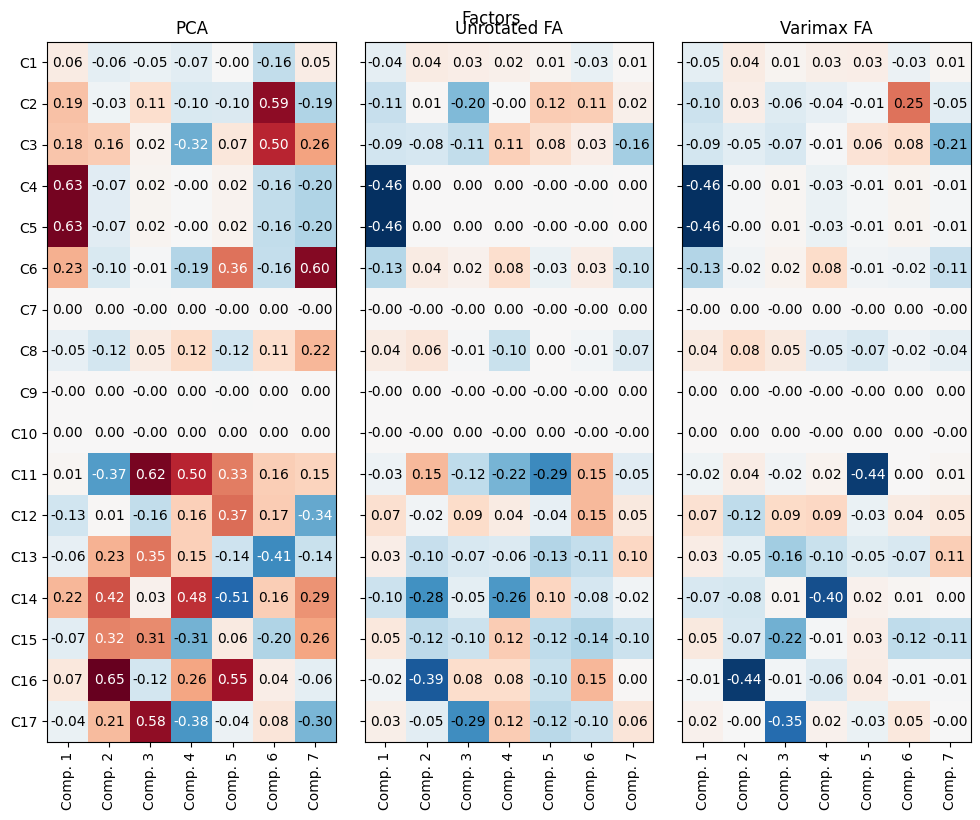

In [903]:
n_comps = 7
feature_names = np.arange(1, num_feats+1)
#feature_names = np.array([x for x in np.arange(1, 18) if x not in [7, 9, 10]])

if version_str == "v3":
    feat_list = list(np.arange(1, 17+1))
    feat_list.remove(5)
    feat_list.remove(7)
    feat_list.remove(10)
    temp_feat_names = ["C" + str(x) for x in feat_list]
else:
    temp_feat_names = ["C" + str(x) for x in feature_names]

methods = [
    ("PCA", PCA()),
    ("Unrotated FA", FactorAnalysis()),
    ("Varimax FA", FactorAnalysis(rotation="varimax")),
    # ("Quartimax FA", FactorAnalysis(rotation="quartimax")),
]
fig, axes = plt.subplots(ncols=len(methods), figsize=(10, 8), sharey=True)

for ax, (method, fa) in zip(axes, methods):
    fa.set_params(n_components=n_comps)
    fa.fit(df[feature_names])

    components = fa.components_.T
    print("\n\n %s :\n" % method)
    print(components)

    vmax = np.abs(components).max()
    ax.imshow(components, cmap="RdBu_r", vmax=vmax, vmin=-vmax)
    # Annotate all cells in the heatmap
    for i in range(components.shape[0]):
        for j in range(components.shape[1]):
            ax.text(
                j, i,
                f"{components[i, j]:.2f}", # Text formatted to two decimal places
                ha="center",
                va="center",
                color="white" if abs(components[i, j]) > 0.31 else "black" # Adjust text color based on cell value for readability
            )
    ax.set_yticks(np.arange(len(temp_feat_names)))
    ax.set_yticklabels(temp_feat_names)
    ax.set_title(str(method))
    ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(["Comp. 1", "Comp. 2", "Comp. 3", "Comp. 4", "Comp. 5", "Comp. 6", "Comp. 7"])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
fig.suptitle("Factors")
plt.tight_layout()
plt.show()

In [904]:
temp_df = pd.DataFrame((df[feature_names].to_numpy() @ components), index=df['Name'], columns=[1, 2, 3, 4, 5, 6, 7])

temp_df

,1,2,3,4,5,6,7
Name,,,,,,,
Oedipus,-1.09,-0.60,-0.63,-0.49,-0.56,0.10,-0.14
Theseus,-1.22,-0.58,-0.48,-0.48,-0.52,0.29,-0.24
Romulus,-1.23,-0.10,-0.78,-0.52,-0.50,0.15,-0.40
Heracles,-1.19,-0.77,-0.74,-0.46,0.02,0.19,-0.32
Perseus,-1.14,-0.25,-0.68,-0.45,-0.09,0.18,-0.36
Jason,-1.23,-0.10,-0.78,-0.52,-0.50,0.15,-0.40
Bellerophon,-0.10,-0.66,-0.72,-0.53,-0.02,0.17,-0.24
Pelops,-1.03,-0.20,-0.71,-0.51,-0.51,0.21,-0.24
Asclepius,-1.12,-0.68,-0.74,-0.05,-0.00,0.19,-0.32


In [905]:
temp_df.mean()

1   -0.84
2   -0.34
3   -0.56
4   -0.33
5   -0.32
6    0.15
7   -0.30
dtype: float64

In [906]:
pd.DataFrame(np.where(temp_df * np.sign(temp_df.mean()) >= 0, "X", ""), index=df['Name'], columns=[1, 2, 3, 4, 5, 6, 7]).sort_index()

,1,2,3,4,5,6,7
Name,,,,,,,
Achilles,X,X,X,,X,X,X
Aeneas,X,X,X,,X,X,X
Apollo,X,X,,,X,X,X
Arthur,X,X,X,X,X,X,X
Asclepius,X,X,X,X,X,X,X
Bellerophon,X,X,X,X,X,X,X
Cadmus,,X,X,,X,,X
Cúchulainn,X,X,X,X,X,X,X
Dionysus,X,X,X,X,X,X,X


In [907]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
# scaler = StandardScaler()

next_temp_df = pd.DataFrame(scaler.fit_transform(temp_df), index=df['Name'], columns=[1, 2, 3, 4, 5, 6, 7])* np.sign(temp_df.mean())

print(next_temp_df.reset_index().to_latex(index=False))

\begin{tabular}{lrrrrrrr}
\toprule
Name & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\
\midrule
Oedipus & 0.787548 & 0.567952 & 0.638672 & 0.815010 & 0.890701 & 0.105826 & -0.179611 \\
Theseus & 0.976657 & 0.507895 & 0.278298 & 0.802089 & 0.775179 & 0.892450 & 0.184222 \\
Romulus & 1.000000 & -0.779490 & 1.000000 & 0.931102 & 0.696757 & 0.300536 & 0.727317 \\
Heracles & 0.943668 & 1.000000 & 0.887699 & 0.717879 & -1.000000 & 0.498716 & 0.461510 \\
Perseus & 0.869016 & -0.371709 & 0.747968 & 0.675397 & -0.640679 & 0.444008 & 0.585032 \\
Jason & 1.000000 & -0.779490 & 1.000000 & 0.931102 & 0.696757 & 0.300536 & 0.727317 \\
Bellerophon & -0.641174 & 0.724596 & 0.857386 & 0.965347 & -0.862491 & 0.407110 & 0.177206 \\
Pelops & 0.701987 & -0.513570 & 0.821369 & 0.894078 & 0.746938 & 0.552640 & 0.172943 \\
Asclepius & 0.837849 & 0.784989 & 0.906155 & -0.585683 & -0.936560 & 0.461202 & 0.466716 \\
Dionysus & 0.910695 & 0.699796 & 0.814149 & 0.832820 & 0.678207 & 0.420115 & 0.575689 \\
Zeus & 0.804876 & 0.4847

In [908]:
next_temp_df

,1,2,3,4,5,6,7
Name,,,,,,,
Oedipus,0.79,0.57,0.64,0.82,0.89,0.11,-0.18
Theseus,0.98,0.51,0.28,0.80,0.78,0.89,0.18
Romulus,1.00,-0.78,1.00,0.93,0.70,0.30,0.73
Heracles,0.94,1.00,0.89,0.72,-1.00,0.50,0.46
Perseus,0.87,-0.37,0.75,0.68,-0.64,0.44,0.59
Jason,1.00,-0.78,1.00,0.93,0.70,0.30,0.73
Bellerophon,-0.64,0.72,0.86,0.97,-0.86,0.41,0.18
Pelops,0.70,-0.51,0.82,0.89,0.75,0.55,0.17
Asclepius,0.84,0.78,0.91,-0.59,-0.94,0.46,0.47


In [909]:
pd.DataFrame(np.where(next_temp_df >= 0, "X", ""), index=df['Name'], columns=[1, 2, 3, 4, 5, 6, 7]).sort_index()

,1,2,3,4,5,6,7
Name,,,,,,,
Achilles,,,X,,,X,X
Aeneas,,,X,,X,X,X
Apollo,X,,,,,X,X
Arthur,,,X,X,X,X,X
Asclepius,X,X,X,,,X,X
Bellerophon,,X,X,X,,X,X
Cadmus,,,X,,X,,
Cúchulainn,X,,X,X,,X,X
Dionysus,X,X,X,X,X,X,X


In [910]:
print(pd.DataFrame(np.where(next_temp_df >= 0, "X", ""), index=df['Name'], columns=[1, 2, 3, 4, 5, 6, 7]).sort_index().reset_index().to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
Name & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\
\midrule
Achilles &  &  & X &  &  & X & X \\
Aeneas &  &  & X &  & X & X & X \\
Apollo & X &  &  &  &  & X & X \\
Arthur &  &  & X & X & X & X & X \\
Asclepius & X & X & X &  &  & X & X \\
Bellerophon &  & X & X & X &  & X & X \\
Cadmus &  &  & X &  & X &  &  \\
Cúchulainn & X &  & X & X &  & X & X \\
Dionysus & X & X & X & X & X & X & X \\
Fereydun & X &  &  & X & X & X &  \\
Fionn mac Cumhaill & X &  & X &  & X & X & X \\
Gilgamesh (Hel) & X &  & X &  &  & X & X \\
Heracles & X & X & X & X &  & X & X \\
Horus & X &  &  &  & X & X & X \\
Jason & X &  & X & X & X & X & X \\
Karna & X &  & X & X &  & X & X \\
Krishna & X &  & X & X & X & X & X \\
Lleu Llaw Gyffes &  & X &  & X &  &  & X \\
Maui & X &  & X & X &  & X & X \\
Moses & X & X &  & X & X & X & X \\
Mwindo & X &  &  & X & X & X & X \\
Nezha & X & X & X & X &  & X & X \\
Nyikang &  &  & X &  & X &  &  \\
Oedipus & X & X & X & X & X & X &  \\
Pelops & X &  & X

In [911]:
def minmax_col(col_vals, high_val = 1, low_val = -1):
    min_val = np.min(col_vals)
    max_val = np.max(col_vals)
    scaled_col_vals = (high_val - low_val)*(col_vals - min_val) / (max_val - min_val) + low_val

    if np.abs(min_val) > np.abs(max_val) and np.mean(col_vals) < 0.0:
        scaled_col_vals *= -1
    # scaled_col_vals *= np.sign(np.mean(col_vals))

    return scaled_col_vals

temp_df.apply(lambda col: minmax_col(col))

,1,2,3,4,5,6,7
Name,,,,,,,
Oedipus,0.79,0.57,0.64,0.82,0.89,0.11,-0.18
Theseus,0.98,0.51,0.28,0.80,0.78,0.89,0.18
Romulus,1.00,-0.78,1.00,0.93,0.70,0.30,0.73
Heracles,0.94,1.00,0.89,0.72,-1.00,0.50,0.46
Perseus,0.87,-0.37,0.75,0.68,-0.64,0.44,0.59
Jason,1.00,-0.78,1.00,0.93,0.70,0.30,0.73
Bellerophon,-0.64,0.72,0.86,0.97,-0.86,0.41,0.18
Pelops,0.70,-0.51,0.82,0.89,0.75,0.55,0.17
Asclepius,0.84,0.78,0.91,-0.59,-0.94,0.46,0.47


In [912]:
temp_df / (temp_df.std() * np.sign(temp_df.mean()))

,1,2,3,4,5,6,7
Name,,,,,,,
Oedipus,2.20,2.27,2.54,2.07,2.31,0.81,1.10
Theseus,2.47,2.18,1.94,2.06,2.17,2.44,1.89
Romulus,2.50,0.36,3.15,2.22,2.07,1.21,3.06
Heracles,2.42,2.88,2.96,1.94,-0.07,1.62,2.49
Perseus,2.32,0.94,2.73,1.89,0.38,1.51,2.75
Jason,2.50,0.36,3.15,2.22,2.07,1.21,3.06
Bellerophon,0.20,2.49,2.91,2.27,0.10,1.43,1.87
Pelops,2.08,0.74,2.85,2.18,2.13,1.73,1.86
Asclepius,2.27,2.58,2.99,0.23,0.01,1.54,2.50


[0.24250104 0.16157745 0.13198748 0.11413357 0.09839983 0.06134111
 0.05783871 0.04044606 0.02728294]
[0.24250104 0.40407849 0.53606597 0.65019954 0.74859938 0.80994048
 0.86777919 0.90822525 0.93550819]


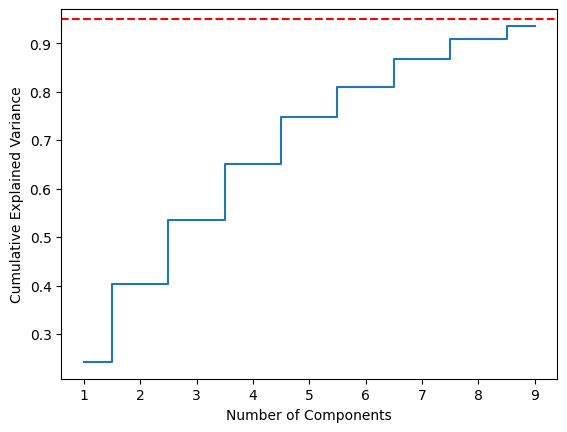

In [913]:
pca = PCA(n_components=9)

X_train = pca.fit_transform(df[feature_names])
X_test = pca.transform(df[feature_names])

explained_variance = pca.explained_variance_ratio_
print(explained_variance)
print(np.cumsum(explained_variance))

exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

# 4. Plot
plt.step(range(1, len(exp_var_cumul)+1), exp_var_cumul, where='mid')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.axhline(y=0.95, color='r', linestyle='--') # 95% threshold
plt.show()

In [914]:
df[feature_names].sum(axis=1)

0     16
1     16
2     15
3     15
4     15
5     15
6     13
7     15
8     14
9     17
10    16
11    16
12    14
13    10
14    14
15    12
16    11
17    15
18    12
19    13
20    13
21    13
22    16
23    14
24    16
25    17
26    13
27    12
28    11
29    15
30    13
31    13
32    14
33    14
34     9
35    14
dtype: int64

In [915]:
# from girth.synthetic import create_synthetic_irt_dichotomous
from girth import twopl_mml

# # 1. Create synthetic data (replace with your actual data)
#    This example generates data for 10 items and 500 individuals.
# difficulty = np.linspace(-2.5, 2.5, 10)
# discrimination = np.random.rand(10) + 0.5
# theta = np.random.randn(500)
# 'syn_data' is a 2D numpy array with 0s and 1s
# syn_data = create_synthetic_irt_dichotomous(difficulty, discrimination, theta)

syn_data = df[feature_names].T.to_numpy()

# 2. Fit the 2PL model using Maximum Marginal Likelihood (MML)
estimates = twopl_mml(syn_data)

# 3. Unpack and view the estimated parameters
discrimination_estimates = estimates['Discrimination']
difficulty_estimates = estimates['Difficulty']
ability_estimates = estimates['Ability']

print("Estimated Discrimination Parameters:", discrimination_estimates)
print("Estimated Difficulty Parameters:", difficulty_estimates)

Estimated Discrimination Parameters: [1.59348869 1.27926125 0.89629694 4.99999524 4.99999524 1.06464461
 0.20000342 0.49357333 0.20000342 0.20000342 0.20000342 0.35608506
 0.31680508 0.48201676 0.27752258 0.20000342 0.21860106]
Estimated Difficulty Parameters: [-2.91803023 -2.05713096 -2.3323095  -0.54000964 -0.54000964 -1.82310708
  6.         -5.81680215  6.          6.         -1.69925011 -5.81929307
 -5.71445087 -1.7929615  -5.72757214  2.28228476 -5.62389372]


In [916]:
estimates

{'Discrimination': array([1.59348869, 1.27926125, 0.89629694, 4.99999524, 4.99999524,
        1.06464461, 0.20000342, 0.49357333, 0.20000342, 0.20000342,
        0.20000342, 0.35608506, 0.31680508, 0.48201676, 0.27752258,
        0.20000342, 0.21860106]),
 'Difficulty': array([-2.91803023, -2.05713096, -2.3323095 , -0.54000964, -0.54000964,
        -1.82310708,  6.        , -5.81680215,  6.        ,  6.        ,
        -1.69925011, -5.81929307, -5.71445087, -1.7929615 , -5.72757214,
         2.28228476, -5.62389372]),
 'Ability': array([ 0.66518912,  0.99036687,  0.83471956,  0.76352809,  0.92003813,
         0.83471956, -1.01294537,  0.50570855,  0.54209396,  1.16061095,
         0.87460934,  1.02525496, -0.86159451, -1.60063251,  0.3466864 ,
        -1.08521143,  0.34766298,  0.87706254, -0.95472193, -1.27488367,
        -0.92611487,  0.53247141,  1.03640869,  0.73236912,  1.03640869,
         1.16061095, -0.92611487,  0.41761195, -1.32017703,  0.76937057,
         0.38279401, -0.90

(array([ 1.,  4.,  6.,  0.,  0.,  0.,  0.,  8., 10.,  7.]),
 array([-1.60063251, -1.32450817, -1.04838382, -0.77225947, -0.49613513,
        -0.22001078,  0.05611357,  0.33223791,  0.60836226,  0.8844866 ,
         1.16061095]),
 <BarContainer object of 10 artists>)

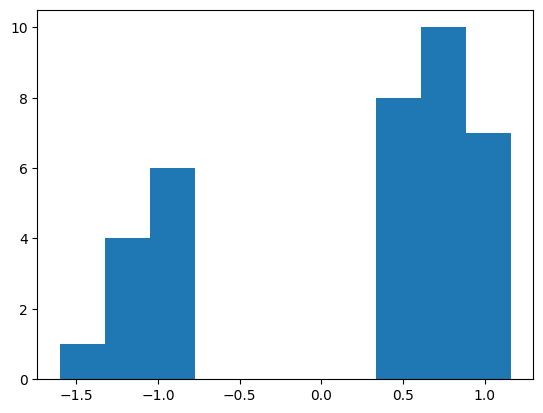

In [917]:
plt.hist(ability_estimates)

In [918]:
np.mean(ability_estimates)

np.float64(0.17983876190966483)

Text(0.5, 1.0, 'Discrimination & Difficulty of Revised Raglan Criteria')

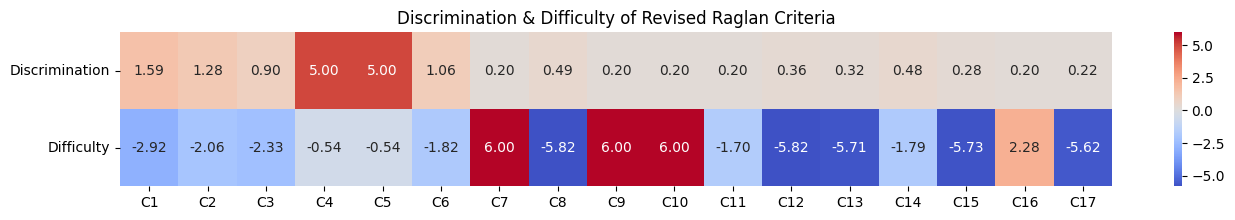

In [919]:
import seaborn as sns

matrix_irt = pd.DataFrame([discrimination_estimates, difficulty_estimates], 
                            index=['Discrimination', 'Difficulty'], 
                            columns=temp_feat_names)
                            # columns=np.arange(1,len(discrimination_estimates)+1))

plt.figure(figsize=(16, 2))
sns.heatmap(matrix_irt, 
            cmap="coolwarm", 
            annot=True, fmt='.2f', 
            center=0, 
            )

plt.title("Discrimination & Difficulty of Revised Raglan Criteria")

In [920]:
print(matrix_irt.T.to_latex(index=True, float_format="{:.2f}".format))

\begin{tabular}{lrr}
\toprule
 & Discrimination & Difficulty \\
\midrule
C1 & 1.59 & -2.92 \\
C2 & 1.28 & -2.06 \\
C3 & 0.90 & -2.33 \\
C4 & 5.00 & -0.54 \\
C5 & 5.00 & -0.54 \\
C6 & 1.06 & -1.82 \\
C7 & 0.20 & 6.00 \\
C8 & 0.49 & -5.82 \\
C9 & 0.20 & 6.00 \\
C10 & 0.20 & 6.00 \\
C11 & 0.20 & -1.70 \\
C12 & 0.36 & -5.82 \\
C13 & 0.32 & -5.71 \\
C14 & 0.48 & -1.79 \\
C15 & 0.28 & -5.73 \\
C16 & 0.20 & 2.28 \\
C17 & 0.22 & -5.62 \\
\bottomrule
\end{tabular}



In [921]:
# print(pd.DataFrame([df['Name'], np.array([f"{item:.2f}" for item in ability_estimates]), df['TOTAL']], 
print(pd.DataFrame([df['Name'], np.array([round(item, 2) for item in ability_estimates]), df['TOTAL']], 
            index=['Name', 'Ability', 'Score']).T\
                .sort_values(by='Ability', ascending=False).reset_index(drop=True).to_latex(index=False, float_format="{:.2f}".format))

\begin{tabular}{lll}
\toprule
Name & Ability & Score \\
\midrule
Yudhishthira & 1.16 & 17 \\
Dionysus & 1.16 & 17 \\
Krishna & 1.04 & 16 \\
Nezha & 1.04 & 16 \\
Moses & 1.03 & 16 \\
Theseus & 0.99 & 16 \\
Perseus & 0.92 & 15 \\
Siegfried & 0.88 & 15 \\
Zeus & 0.87 & 16 \\
Romulus & 0.83 & 15 \\
Jason & 0.83 & 15 \\
Fionn mac Cumhaill & 0.77 & 15 \\
Heracles & 0.76 & 15 \\
Mwindo & 0.74 & 14 \\
Maui & 0.73 & 14 \\
Karna & 0.73 & 14 \\
Oedipus & 0.67 & 16 \\
Asclepius & 0.54 & 14 \\
Gilgamesh (Hel) & 0.53 & 13 \\
Pelops & 0.51 & 15 \\
Cúchulainn & 0.43 & 14 \\
Horus & 0.42 & 12 \\
Fereydun & 0.38 & 13 \\
Apollo & 0.35 & 11 \\
Watu Gunung & 0.35 & 14 \\
Arthur & -0.86 & 14 \\
Thánh Gióng & -0.90 & 13 \\
Rama & -0.93 & 13 \\
Aeneas & -0.93 & 13 \\
Achilles & -0.95 & 12 \\
Bellerophon & -1.01 & 13 \\
Lleu Llaw Gyffes & -1.09 & 12 \\
Sun Wukong & -1.27 & 13 \\
Cadmus & -1.32 & 11 \\
Rostam & -1.32 & 9 \\
Nyikang & -1.60 & 10 \\
\bottomrule
\end{tabular}



In [922]:
from scipy.stats import pearsonr

def calculate_q3(response_data, theta_estimates, item_params_df):
    """
    Calculates Yen's Q3 local dependence statistic for all item pairs.

    Args:
        response_data (pd.DataFrame): DataFrame of observed binary responses (0 or 1).
        theta_estimates (np.array): Estimated latent abilities (theta) for each person.
        item_params_df (pd.DataFrame): DataFrame with 'discrimination' and 'difficulty' 
                                      columns for each item.

    Returns:
        pd.DataFrame: A matrix of Q3 statistics for all item pairs.
    """
    num_items = response_data.shape[1]
    q3_matrix = pd.DataFrame(np.zeros((num_items, num_items)), columns=response_data.columns, index=response_data.columns)

    # 1. Calculate expected probabilities P(Y_j=1|theta) for all respondents and items
    # Using 2PL model formula: P = 1 / (1 + exp(-a * (theta - b)))
    discrimination = item_params_df['Discrimination']#.values
    difficulty = item_params_df['Difficulty']#.values
    
    # Expand theta to a matrix where each column is the theta for all items for a person
    theta_matrix = np.tile(theta_estimates, (num_items, 1)).T
    discrimination_matrix = np.tile(discrimination, (response_data.shape[0], 1))
    difficulty_matrix = np.tile(difficulty, (response_data.shape[0], 1))

    expected_probs = 1 / (1 + np.exp(-discrimination_matrix * (theta_matrix - difficulty_matrix)))

    # 2. Calculate residuals (Observed - Expected)
    residuals = response_data.values - expected_probs

    # 3. Calculate conditional correlation (Q3) for all pairs
    for i in range(num_items):
        for j in range(i + 1, num_items):
            item_i_res = residuals[:, i]
            item_j_res = residuals[:, j]
            
            # Yen's Q3 is the pearson correlation of the residuals
            # Note: A more rigorous approach involves weighting by the information function 
            # as per the formal definition, but simple correlation is a common approximation.
            q3_val, _ = pearsonr(item_i_res, item_j_res)
            q3_matrix.iloc[i, j] = q3_val
            q3_matrix.iloc[j, i] = q3_val # Matrix is symmetric

    return q3_matrix

# Example Usage (requires fitted model data)
# Replace with your actual data and parameters
# Assuming 'response_data' is a pandas DataFrame, 'theta_estimates' is a numpy array
# and 'item_params_df' is a pandas DataFrame

# Example dummy data (replace with real data)
# data = pd.DataFrame(np.random.randint(0, 2, size=(100, 10)), columns=[f'Item_{i+1}' for i in range(10)])
# theta = np.random.randn(100)
# params = pd.DataFrame({'discrimination': np.random.rand(10) + 0.5, 'difficulty': np.random.randn(10)})

# q3_results = calculate_q3(data, theta, params)
# print(q3_results)

In [923]:
q_corr = pd.DataFrame(calculate_q3(df[feature_names], df[feature_names].sum(axis=1), estimates))
q_corr.columns = temp_feat_names
q_corr.index = temp_feat_names
q_corr

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17
C1,0.00,-0.06,-0.07,0.25,0.25,0.38,-0.06,-0.04,-0.06,-0.06,-0.15,-0.06,-0.07,-0.11,-0.08,-0.22,-0.09
C2,-0.06,0.00,0.37,0.34,0.34,0.08,-0.42,-0.09,-0.42,-0.42,0.05,-0.13,-0.14,0.15,-0.16,-0.11,0.23
C3,-0.07,0.37,0.00,0.26,0.26,0.25,-0.51,-0.10,-0.51,-0.51,-0.20,-0.14,-0.16,0.08,0.25,0.12,0.16
C4,0.25,0.34,0.26,0.00,1.00,0.35,-0.64,-0.16,-0.64,-0.64,0.03,-0.24,-0.10,0.21,-0.14,-0.01,-0.08
C5,0.25,0.34,0.26,1.00,0.00,0.35,-0.64,-0.16,-0.64,-0.64,0.03,-0.24,-0.10,0.21,-0.14,-0.01,-0.08
C6,0.38,0.08,0.25,0.35,0.35,0.00,-0.40,-0.11,-0.40,-0.40,0.06,-0.16,-0.18,-0.14,-0.00,0.02,-0.07
C7,-0.06,-0.42,-0.51,-0.64,-0.64,-0.40,0.00,0.09,1.00,1.00,-0.23,0.14,-0.25,-0.41,-0.32,-0.31,-0.36
C8,-0.04,-0.09,-0.10,-0.16,-0.16,-0.11,0.09,0.00,0.09,0.09,0.29,-0.09,-0.10,0.10,-0.11,-0.30,-0.13
C9,-0.06,-0.42,-0.51,-0.64,-0.64,-0.40,1.00,0.09,0.00,1.00,-0.23,0.14,-0.25,-0.41,-0.32,-0.31,-0.36
C10,-0.06,-0.42,-0.51,-0.64,-0.64,-0.40,1.00,0.09,1.00,0.00,-0.23,0.14,-0.25,-0.41,-0.32,-0.31,-0.36


In [924]:
q_corr.stack().mean()

np.float64(-0.048985001810485505)

In [925]:
q_corr.abs().mean(axis=None)

np.float64(0.2247548479583741)

In [926]:
import math

q_corr.abs().sum().sum()/math.comb(len(estimates['Discrimination']), 2)

np.float64(0.47760405191154487)

In [927]:
q_corr.abs().mean(axis=None)/math.comb(len(estimates['Discrimination']), 2)

np.float64(0.0016526091761645155)

Text(0.5, 1.0, "Yen's $Q_3$ for Revised Raglan Criteria")

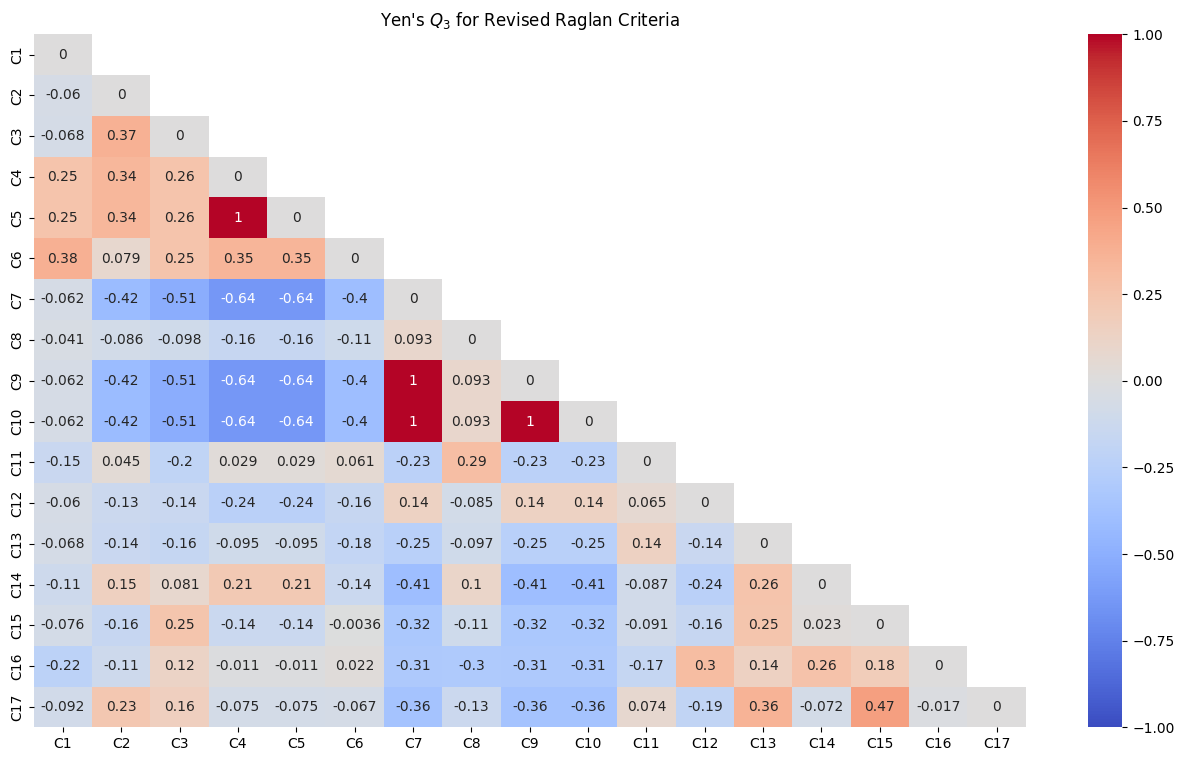

In [928]:
import seaborn as sns


mask = np.triu(np.ones_like(q_corr, dtype=bool), k=1)
plt.figure(figsize=(16, 9))
sns.heatmap(q_corr, mask=mask, 
            cmap="coolwarm", 
            annot=True, center=0, 
            vmin=-1, vmax=1)

plt.title("Yen's $Q_3$ for Revised Raglan Criteria")

Text(0.5, 1.0, 'Cosine Similarity between Features')

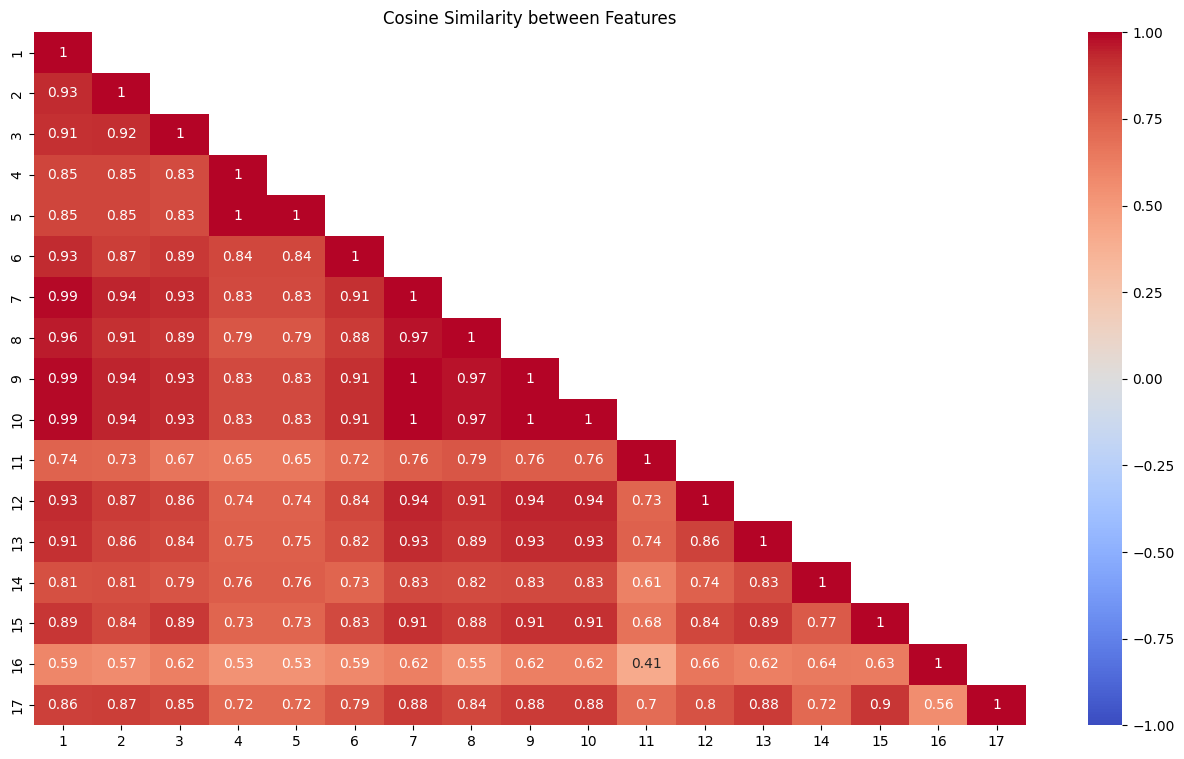

In [929]:
from sklearn.metrics.pairwise import cosine_similarity

plt.figure(figsize=(16, 9))
sns.heatmap(pd.DataFrame(cosine_similarity(df[feature_names].T), 
                        columns = df[feature_names].columns, 
                        index = df[feature_names].columns), mask=mask, 
            cmap="coolwarm", 
            annot=True, center=0, 
            vmin=-1, vmax=1)

plt.title("Cosine Similarity between Features")

In [930]:
df = df[df['Name'] != 'Jesus']

In [931]:
df['Name'].tolist()

['Oedipus',
 'Theseus',
 'Romulus',
 'Heracles',
 'Perseus',
 'Jason',
 'Bellerophon',
 'Pelops',
 'Asclepius',
 'Dionysus',
 'Zeus',
 'Moses',
 'Arthur',
 'Nyikang',
 'Watu Gunung',
 'Lleu Llaw Gyffes',
 'Apollo',
 'Siegfried',
 'Achilles',
 'Sun Wukong',
 'Aeneas',
 'Gilgamesh (Hel)',
 'Nezha',
 'Karna',
 'Krishna',
 'Yudhishthira',
 'Rama',
 'Horus',
 'Cadmus',
 'Fionn mac Cumhaill',
 'Fereydun',
 'Thánh Gióng',
 'Mwindo',
 'Cúchulainn',
 'Rostam',
 'Maui']

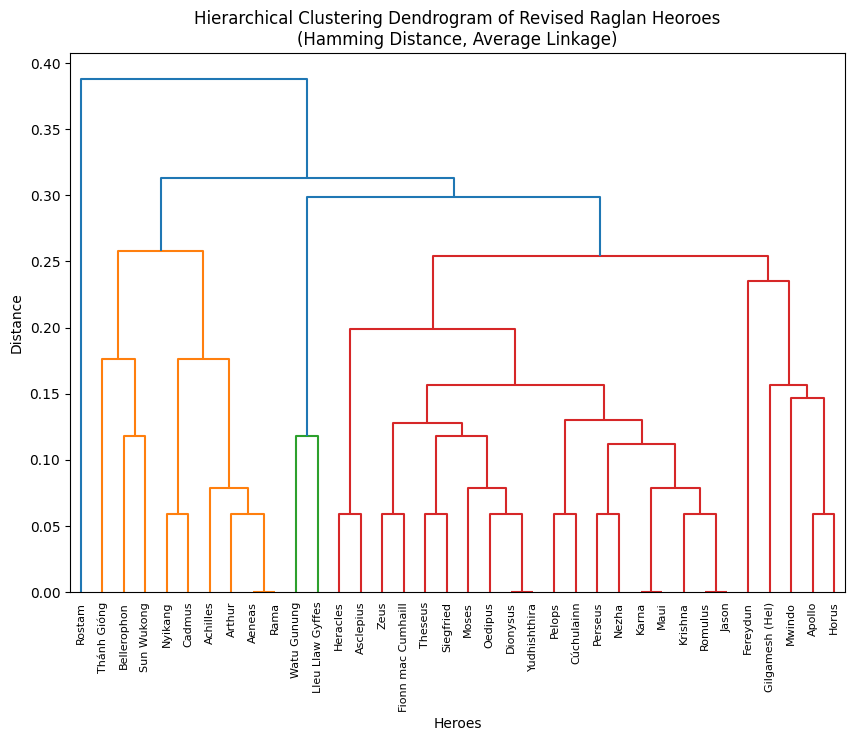

Cluster labels: [ 8  7  3 11  0  3  2 10 11  8  6 19  5  4 14 12  1  7 18  2  5 16  0  0
  3  8  5  1  4  6 17 15 13 10  9  0]


In [932]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import squareform

labels_list = df['Name'].tolist()

# Calculate the distance matrix using the Hamming distance
# 'pdist' returns a condensed distance matrix (1D array)
distance_matrix = pdist(df[feature_names], metric='hamming')
# For Jaccard distance, use metric='jaccard'
# distance_matrix = pdist(data, metric='jaccard')

# Perform agglomerative hierarchical clustering using the 'complete' linkage method
# linked_data = linkage(distance_matrix, method='complete')
linked_data = linkage(distance_matrix, method='average')
# Other methods: 'single', 'average', 'ward' (ward is usually for Euclidean distance)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
# dendrogram(linked_data, labels=[f"Obs {i+1}" for i in range(len(data))])
dendrogram(linked_data, labels=labels_list, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Revised Raglan Heoroes\n(Hamming Distance, Average Linkage)')
plt.xlabel('Heroes')
plt.ylabel('Distance')
plt.show()

# Define the number of clusters (e.g., 2 clusters)
n_clusters = 20

# Use AgglomerativeClustering with precomputed distances
# The 'affinity' parameter must be set to 'precomputed' and 'linkage' to a suitable method
model = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')

# Fit the model using the square form of the distance matrix (required by sklearn)
# Note: you need to convert the condensed distance matrix to a square form for sklearn
square_distance_matrix = squareform(distance_matrix)

cluster_labels = model.fit_predict(square_distance_matrix)

print(f"Cluster labels: {cluster_labels}")

Text(0.5, 1.0, 'Jaccard Distance between Heroes')

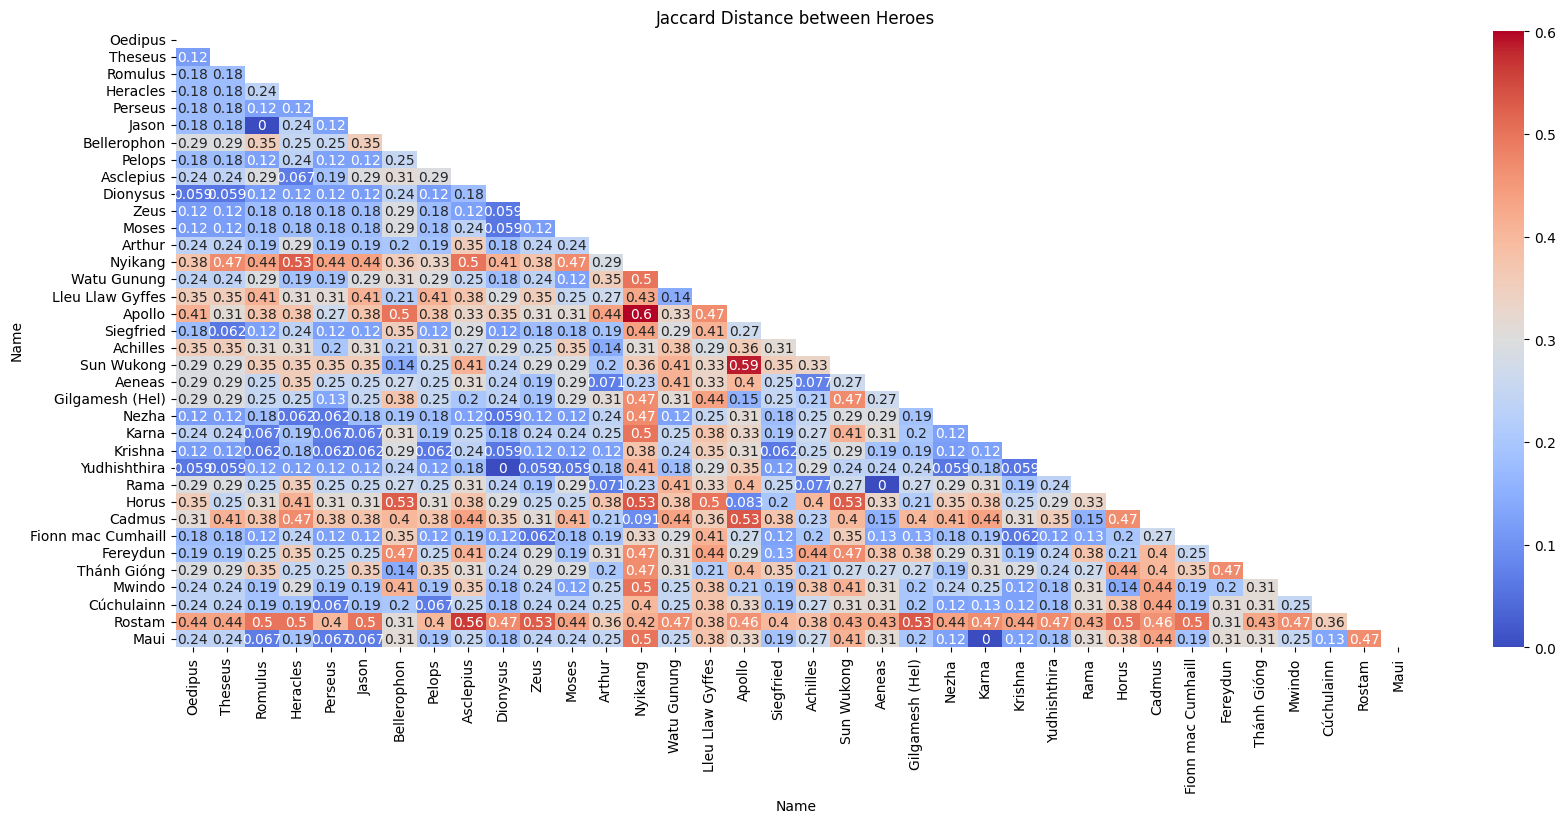

In [933]:
from scipy.spatial.distance import pdist, squareform

distances = pdist(df[feature_names], metric='jaccard')
distance_matrix = squareform(distances)
# print(pd.DataFrame(distance_matrix))

mask = np.triu(np.ones_like(pd.DataFrame(distance_matrix), dtype=bool), k=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pd.DataFrame(distance_matrix, index=df['Name'], columns=df['Name']), mask=mask, 
            cmap="coolwarm", 
            annot=True, #center=0.5, 
            vmin=0, vmax=np.max(distance_matrix))

plt.title("Jaccard Distance between Heroes")

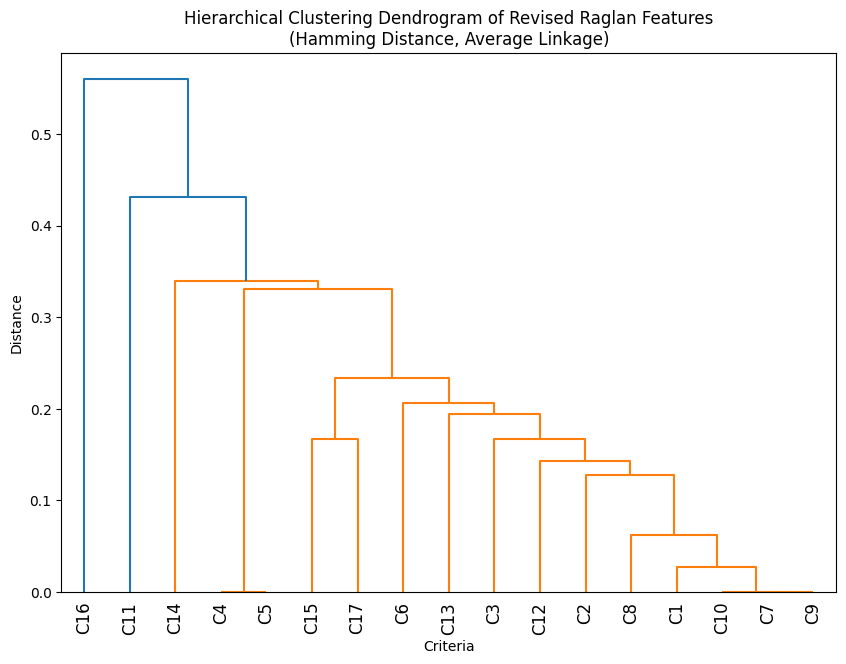

Cluster labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [934]:
labels_list = np.arange(1, len(feature_names) + 1)

# Calculate the distance matrix using the Hamming distance
# 'pdist' returns a condensed distance matrix (1D array)
distance_matrix = pdist(df[feature_names].T, metric='hamming')
# For Jaccard distance, use metric='jaccard'
# distance_matrix = pdist(data, metric='jaccard')

# Perform agglomerative hierarchical clustering using the 'complete' linkage method
# linked_data = linkage(distance_matrix, method='complete')
linked_data = linkage(distance_matrix, method='average')
# Other methods: 'single', 'average', 'ward' (ward is usually for Euclidean distance)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked_data, labels=[f"C{i+1}" for i in range(len(labels_list))], leaf_rotation=90)
# dendrogram(linked_data, labels=labels_list, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Revised Raglan Features\n(Hamming Distance, Average Linkage)')
plt.xlabel('Criteria')
plt.ylabel('Distance')
plt.show()

# Define the number of clusters (e.g., 2 clusters)
n_clusters = 2

# Use AgglomerativeClustering with precomputed distances
# The 'affinity' parameter must be set to 'precomputed' and 'linkage' to a suitable method
model = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')

# Fit the model using the square form of the distance matrix (required by sklearn)
# Note: you need to convert the condensed distance matrix to a square form for sklearn
square_distance_matrix = squareform(distance_matrix)

cluster_labels = model.fit_predict(square_distance_matrix)

print(f"Cluster labels: {cluster_labels}")

In [935]:
print(feature_names)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [936]:
import hdbscan

# Initialize the HDBSCAN clusterer with the Jaccard metric
clusterer = hdbscan.HDBSCAN(metric='jaccard', min_cluster_size=2) # Adjust parameters as needed

# Fit the clusterer to the data
clusterer.fit(df[feature_names])

# Get the cluster labels
labels = clusterer.labels_
print(f"Cluster labels: {labels}")

Cluster labels: [ 1  1  1  1  1  1 -1  1 -1  1  1  1  0 -1  1 -1 -1  1  0 -1  0 -1  1  1
  1  1  0 -1 -1  1 -1 -1 -1  1 -1  1]


/Users/aaronadair/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


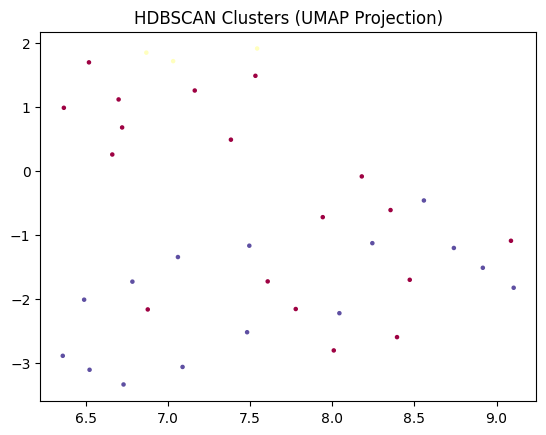

In [937]:
import umap.umap_ as umap

df_new = df[feature_names].copy()

# 2. Apply HDBSCAN (Euclidean is suitable for 0/1 data)
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric='euclidean')
df_new['cluster'] = clusterer.fit_predict(df_new)

# 3. Visualize with UMAP
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(df_new.drop(columns=['cluster']))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df_new['cluster'], cmap='Spectral', s=5)
plt.title('HDBSCAN Clusters (UMAP Projection)')
plt.show()

In [938]:
df_new['Name'] = df['Name']
df_new.sort_values(by='cluster')

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,cluster,Name
0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,-1,Oedipus
31,1,1,1,0,0,1,1,1,1,1,0,1,0,1,1,1,1,-1,Thánh Gióng
30,1,1,0,1,1,1,1,1,1,1,1,1,1,1,0,0,0,-1,Fereydun
27,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,-1,Horus
19,0,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,-1,Sun Wukong
18,1,1,1,0,0,1,1,1,1,1,0,1,1,0,1,0,1,-1,Achilles
34,1,1,0,0,0,0,1,1,1,1,0,1,1,1,0,0,0,-1,Rostam
16,1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,-1,Apollo
15,1,0,1,0,0,1,1,1,1,1,0,1,1,1,1,1,0,-1,Lleu Llaw Gyffes
14,1,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,-1,Watu Gunung


17.0 0.818627444483731


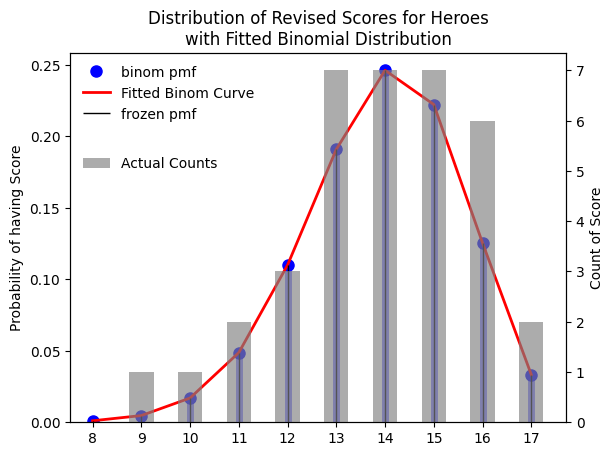

In [939]:
new_counts_list = df['TOTAL'].tolist()

params = scipy.stats.fit(binom, new_counts_list, bounds={"n":[len(feature_names)]}
                         )

n = params.params.n
p = params.params.p

print(n, p)

x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(1.00, n, p))
x = np.arange(int(n//2 + 0), n+1, 1)

fig, ax1 = plt.subplots()

ax1.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='binom pmf')
ax1.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)


ax1.plot(x, binom.pmf(x, n, p), 
            'r-', lw=2, label='Fitted Binom Curve')

rv = binom(n, p)
ax1.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')

ax1.set_ylim(ymin=0)

ax1.legend(loc='best', frameon=False)


ax2 = ax1.twinx()

_, bins, rects = ax2.hist(new_counts_list, bins=np.arange(int(n//2+0) + 0.25, n+0.75, 0.5), 
         density=False, color='grey', label="Actual Counts", alpha=0.65)

ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(loc='center left', bbox_to_anchor=(0.00, 0.7), frameon=False)

plt.title("Distribution of Revised Scores for Heroes\nwith Fitted Binomial Distribution")
plt.xlabel("Revised Score")
ax1.set_ylabel("Probability of having Score")
ax2.set_ylabel("Count of Score")

plt.xticks(np.arange(int(n//2+0), n+0.75, 1.0))

plt.show()
plt.close()

In [940]:
min_ = int(n//2 + 0)
max_ = int(n + 1)

# Binomial
observed_data = [new_counts_list.count(i) for i in range(min_, max_)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, n, p)*tot_obs for x in range(min_, max_)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]

chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

# Binomial Unweighted Coin
observed_data = [new_counts_list.count(i) for i in range(min_, max_)]
tot_obs = np.sum(observed_data)
expected_data = [binom.pmf(x, n, 0.5)*tot_obs for x in range(min_, max_)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]

chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

# Uniform
observed_data = [new_counts_list.count(i) for i in range(min_, max_)]
tot_obs = np.sum(observed_data)
expected_data = [tot_obs/len(observed_data) for x in range(min_, max_)]
expected_data = [x*tot_obs/np.sum(expected_data) for x in expected_data]


chi2, p_value, dof, expected = stats.chi2_contingency(
    [observed_data, expected_data])

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value}")

print(min_, max_)

Chi-square statistic: 1.568421906972786
p-value: 0.996606628873758
Chi-square statistic: 49.04526853301553
p-value: 1.6276959644787578e-07
Chi-square statistic: 11.379659716821322
p-value: 0.2505799328776782
8 18


In [941]:
import arviz as az
import numpy as np
from scipy.stats import beta

# Define the parameters for the Beta distribution (e.g., alpha=5, beta=2)
alpha = 1 + 1 
beta_param = 1 + len(new_counts_list) - 1

# Generate posterior draws (samples) from the Beta distribution
# In a real scenario, these samples would come from your MCMC chain.
samples = beta.rvs(a=alpha, b=beta_param, size=10000)

# Calculate the 95% HDI
# The default hdi_prob is 0.94 in ArviZ, but you can specify 0.95
hdi_interval = az.hdi(samples, hdi_prob=0.95)*100

print(f"Alpha: {alpha}, Beta: {beta_param}")
print(f"Mean: {alpha/(alpha + beta_param)*100}%")
print(f"Mode: {(alpha-1)/(alpha + beta_param - 2)*100}%")
print(f"95% HDI: {hdi_interval}")
# Example output: 95% HDI: [0.51, 0.94]

Alpha: 2, Beta: 36
Mean: 5.263157894736842%
Mode: 2.7777777777777777%
95% HDI: [ 0.11406956 12.26346904]


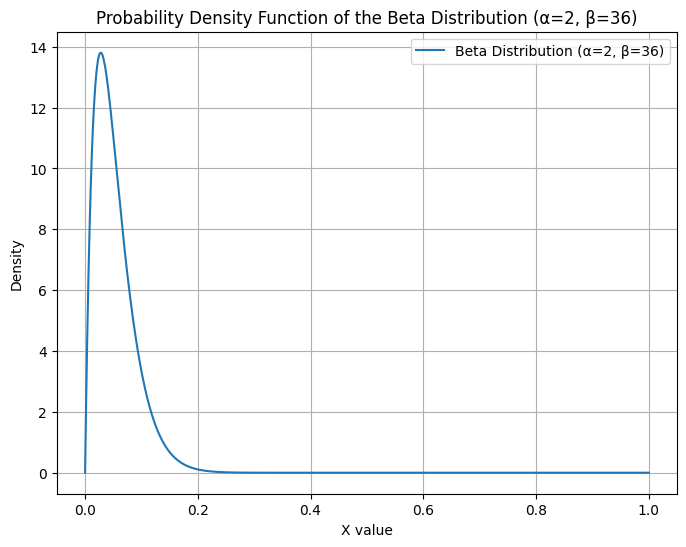

In [942]:
# 2. Generate x-values
# The beta distribution is defined on the interval [0, 1]. 
# We generate a range of values for x within this interval.
x = np.linspace(0, 1, 1000)

# 3. Calculate the Probability Density Function (PDF)
# Use the beta.pdf function from scipy.stats.
# The 'loc' and 'scale' parameters can be used to shift or stretch the distribution 
# beyond the default [0, 1] range, but here we use the default (loc=0, scale=1).
y = beta.pdf(x, alpha, beta_param)

# 4. Plot the distribution
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=f'Beta Distribution (α={alpha}, β={beta_param})')
plt.title(f'Probability Density Function of the Beta Distribution (α={alpha}, β={beta_param})')
plt.xlabel('X value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [943]:
1/2600.

0.0003846153846153846

In [944]:
# from sklearn.manifold import TSNE
# from sklearn.metrics.pairwise import pairwise_distances

# distance_matrix = pairwise_distances(df[feature_names], metric="jaccard")

# # Use t-SNE to reduce dimensionality to 2D
# # Note: Fit t-SNE on the original data or the distance matrix (here using distance matrix)
# tsne = TSNE(n_components=2, metric='precomputed', random_state=42)
# # If using original data, use: tsne = TSNE(n_components=2, random_state=42)
# vis_data = tsne.fit_transform(distance_matrix)

Chi-square value: 389.6637124535425
P-value: 2.5831713389054628e-26
KMO Model: 0.42182098738115825


/Users/aaronadair/miniconda3/lib/python3.10/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/Users/aaronadair/miniconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


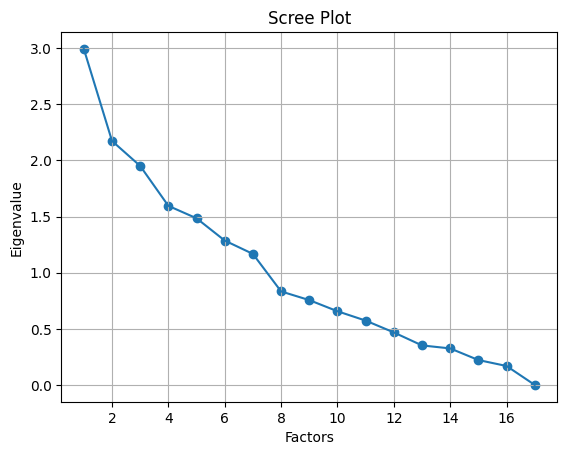

[[ 0.13100848 -0.32344451 -0.1971813 ]
 [ 0.38734301  0.03003844 -0.10514909]
 [ 0.34799352  0.16339173 -0.41176815]
 [ 0.95401454 -0.19614965 -0.05276519]
 [ 0.95495438 -0.19636227 -0.05260585]
 [ 0.31280314 -0.20675835 -0.16711608]
 [-0.42127433 -0.04164724 -0.27115766]
 [-0.08886868 -0.16479729  0.45263242]
 [ 0.04574795  0.08587705  0.55402864]
 [ 0.03448431 -0.24858273  0.00221701]
 [ 0.05677303  0.01214778  0.47148657]
 [-0.31819677 -0.11431443 -0.04027918]
 [-0.01871279  0.55238026  0.27305595]
 [ 0.30297741  0.23136037  0.19724106]
 [-0.00765108  0.59769035 -0.21936664]
 [ 0.09782123  0.30898994 -0.04060989]
 [ 0.04866831  0.58659456 -0.15133559]]
[[ 0.794591    0.15903528  1.15562976]
 [ 0.71461402 -0.48182725  0.50576858]
 [ 1.18081213  0.50880024  0.71585938]
 [ 0.36323915  0.80252111 -1.83721721]
 [ 0.75808951  0.09590907 -0.7080814 ]
 [ 0.63363023  0.26911177  0.31690174]
 [-1.24903062  1.05246831  0.02171122]
 [ 0.70217067  0.27382481 -0.09691897]
 [ 0.37327787  0.5438891

/Users/aaronadair/miniconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/aaronadair/miniconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [945]:
data = df[feature_names]

def add_jitter(column, scale=0.01):
    return column + np.random.uniform(-scale, scale, size=len(column))

# Apply the function to the entire DataFrame (only affects numeric columns)
data = data.apply(add_jitter)

# Apply Bartlett's test
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(data)
print(f'Chi-square value: {chi_square_value}\nP-value: {p_value}')

# Apply KMO test
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(data)
print(f'KMO Model: {kmo_model}')

# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation="promax")
fa.fit(data)

# Check Eigenvalues
eigen_values, vectors = fa.get_eigenvalues()
plt.scatter(range(1, data.shape[1]+1), eigen_values)
plt.plot(range(1, data.shape[1]+1), eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# Perform factor analysis with the determined number of factors
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(data)

# Get factor loadings
loadings = fa.loadings_
print(loadings)

# Get variance of each factor
fa.get_factor_variance()

# Get factor scores
factor_scores = fa.transform(data)
print(factor_scores)

In [946]:
data

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,1.01,1.00,0.00,1.00,1.00,1.00,1.00,0.99,1.01,1.01,1.00,1.01,1.00,1.00,1.00,1.01,1.01
1,1.01,1.00,1.01,0.99,1.00,1.00,1.00,0.99,1.01,1.00,1.00,1.00,0.99,0.99,0.00,0.99,1.01
2,0.99,0.99,1.01,0.99,1.01,1.00,1.00,1.00,1.01,1.00,1.01,-0.01,1.00,1.01,1.00,0.00,1.01
3,1.00,0.99,1.00,1.00,1.00,0.99,1.01,0.01,0.99,0.99,-0.01,0.99,0.99,1.00,1.01,0.99,1.00
4,0.99,1.00,1.00,1.00,0.99,1.00,1.01,1.00,1.00,1.00,-0.01,0.99,1.00,1.00,1.01,-0.00,1.00
5,0.99,1.00,0.99,1.01,1.00,0.99,0.99,1.00,1.00,1.01,1.01,0.01,1.00,1.00,0.99,0.01,1.00
6,1.00,1.00,0.99,-0.00,-0.00,-0.01,0.99,0.99,1.00,1.00,-0.01,1.00,1.01,1.01,1.00,1.01,0.99
7,0.99,1.00,1.00,1.00,1.00,-0.00,1.00,1.01,0.99,1.00,1.01,1.01,1.01,1.00,1.00,-0.01,1.00
8,1.00,1.01,1.00,1.00,1.00,1.00,1.00,0.00,0.99,1.00,0.00,1.01,1.00,-0.00,0.99,1.00,1.00
9,1.00,1.01,1.00,0.99,1.00,0.99,0.99,1.00,0.99,0.99,1.00,1.01,1.00,1.00,1.01,0.99,1.00


In [947]:
import seaborn as sns

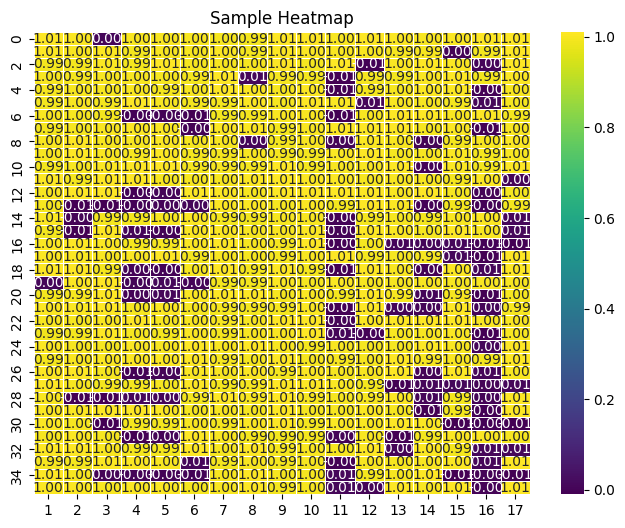

In [948]:
plt.figure(figsize=(8, 6))
sns.heatmap(data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Sample Heatmap')
plt.show()

In [949]:
correlation_matrix = data.corr()

In [950]:
correlation_matrix

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
1,1.00,-0.06,-0.08,0.25,0.25,0.38,0.17,-0.03,-0.11,0.09,-0.14,-0.05,-0.07,-0.12,-0.09,-0.21,-0.10
2,-0.06,1.00,0.37,0.34,0.34,0.08,-0.16,-0.08,-0.04,-0.07,0.06,-0.12,-0.15,0.15,-0.16,-0.08,0.23
3,-0.08,0.37,1.00,0.26,0.26,0.25,-0.09,-0.10,-0.25,0.07,-0.17,-0.14,-0.16,0.08,0.26,0.16,0.17
4,0.25,0.34,0.26,1.00,1.00,0.35,-0.37,-0.16,-0.00,0.03,0.05,-0.24,-0.09,0.21,-0.13,0.03,-0.06
5,0.25,0.34,0.26,1.00,1.00,0.35,-0.37,-0.16,-0.00,0.03,0.06,-0.24,-0.09,0.21,-0.13,0.03,-0.05
6,0.38,0.08,0.25,0.35,0.35,1.00,0.08,-0.11,0.15,0.12,0.08,-0.16,-0.19,-0.13,0.00,0.05,-0.06
7,0.17,-0.16,-0.09,-0.37,-0.37,0.08,1.00,-0.23,-0.11,-0.07,-0.08,0.26,0.11,-0.31,-0.04,-0.22,0.13
8,-0.03,-0.08,-0.10,-0.16,-0.16,-0.11,-0.23,1.00,0.22,0.17,0.29,-0.09,-0.09,0.11,-0.11,-0.31,-0.14
9,-0.11,-0.04,-0.25,-0.00,-0.00,0.15,-0.11,0.22,1.00,-0.02,0.38,-0.00,0.30,0.02,-0.07,0.13,-0.02
10,0.09,-0.07,0.07,0.03,0.03,0.12,-0.07,0.17,-0.02,1.00,-0.06,-0.17,-0.18,-0.05,-0.11,-0.09,-0.17
